# Hidden Markov Model (HMM) Analysis
### Master Thesis: Revisiting Delegation Theory in the Age of AI: Dynamic Algorithm Appreciation and Aversion in Triadic Organizational Relationships

---

### Table of Contents

**Part I — Data and HMM Estimation Framework**

1. [Data Description and Variable Construction](#1-data-description-and-variable-construction)
   - 1.1 &nbsp; [Helpers & Imports](#11-helpers--imports)
   - 1.2 &nbsp; [Benchmark Construction](#12-benchmark-construction)
   - 1.3 &nbsp; [Data Loading & Inspection](#13-data-loading--inspection)
2. [Hidden Markov Model Specification](#2-hidden-markov-model-specification)
   - 2.1 &nbsp; [Model Structure](#21-model-structure)
   - 2.2 &nbsp; [Forward–Backward Algorithm](#22-forwardbackward-algorithm)
   - 2.3 &nbsp; [Maximum Likelihood Estimation](#23-maximum-likelihood-estimation)
3. [Model Selection and Parameter Estimation](#3-model-selection-and-parameter-estimation)
4. [Posterior State Inference and Interpretation](#4-posterior-state-inference-and-interpretation)
   - 4.1 &nbsp; [Posterior State Assignment](#41-posterior-state-assignment)
   - 4.2 &nbsp; [Results Visualisation](#42-results-visualisation)

**Part II — Empirical Findings**

5. [Identification and Characterization of Three Latent Delegation States](#5-identification-and-characterization-of-three-latent-delegation-states)
6. [KPI-Driven Transition Dynamics](#6-kpi-driven-transition-dynamics)
7. [Transparency as Moderator of State Transitions](#7-transparency-as-moderator-of-state-transitions)
8. [Strategic Control Retention Under High Task Stakes](#8-strategic-control-retention-under-high-task-stakes)
9. [Non-Monotonic Relationship Between Delegation and Performance](#9-non-monotonic-relationship-between-delegation-and-performance)
10. [Robustness and Sensitivity Analyses](#10-robustness-and-sensitivity-analyses)

**Part III — Theoretical and Task-Level Implications**

11. [Delegation as Dynamic Learning Process](#11-delegation-as-dynamic-learning-process)
12. [Authority as Strategic and Legitimacy Mechanism](#12-authority-as-strategic-and-legitimacy-mechanism)
13. [Triadic Delegation Flows: Authority vs Execution](#13-triadic-delegation-flows-authority-vs-execution)
14. [Temporal Evolution of Delegation Patterns](#14-temporal-evolution-of-delegation-patterns)

---
# Part I — Data and HMM Estimation Framework

## 1. Data Description and Variable Construction
### 1.1 Helpers & Imports

In [ ]:
# ============================================================
# 1. Imports & Helpers
# ============================================================
from __future__ import annotations

import os
import time
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
from pathlib import Path
from multiprocessing.pool import ThreadPool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---- resolve data path ----
MANUAL_XLSX_PATH = None
PREFERRED_DATASETS = [
    Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx"),
]
DATA_PATH = None
if MANUAL_XLSX_PATH:
    DATA_PATH = Path(MANUAL_XLSX_PATH)
else:
    for p in PREFERRED_DATASETS:
        if p.exists():
            DATA_PATH = p
            break
assert DATA_PATH is not None and DATA_PATH.exists(), \
    f"Data file not found. Tried: {PREFERRED_DATASETS}"
print(f"Data file: {DATA_PATH.resolve()}")


def softmax(z, axis=-1):
    """Numerically stable softmax (works on 1-D vectors and row-wise on 2-D)."""
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


def log_softmax(z, axis=-1):
    """Numerically stable log-softmax."""
    return z - logsumexp(z, axis=axis, keepdims=True)


def log_gaussian_diag(y, mean, log_sigma):
    """Scalar version (kept for reference)."""
    sigma2 = np.exp(2 * log_sigma)
    return -0.5 * (
        np.sum(np.log(2 * np.pi * sigma2))
        + np.sum((y - mean) ** 2 / sigma2)
    )

print("Section 1 — Imports & helpers loaded.")

Data file: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx
Section 1 — Imports & helpers loaded.


### 1.2 Benchmark Construction
Derive performance benchmarks used as **transition covariates**:
- `kpi_operational_gap_index` — composite operational KPIs gap
- `within_unit_temporal_benchmark` — period-over-period KPIs change
- `horizontal_peer_benchmark` — cross-sectional percentile, rank percentile within period
- `within_unit_ai_trajectory_benchmark` — deviation from low-AI baseline (periods with low AI delegation)
- `threshold_benchmark` — recent negative shock indicator, e.g. missing a KPI target, a self-service level breach or forecast failure in the preceding period.

In [ ]:
# ============================================================
# 2. Build Benchmarks
# ============================================================

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()

    # Composite performance index (higher = better)
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )

    # Within-manager temporal benchmark
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )

    # Peer percentile (cross-sectional)
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    # AI trajectory benchmark
    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base

    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )

    # Threshold shock
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # Transparency constant (analysis dataset — no variation)
    df["transparency_moderator"] = 0.0

    return df

print("Section 2 — build_benchmarks() defined.")

Section 2 — build_benchmarks() defined.


### 1.3 Data Loading & Inspection
Load the `panel_manager_period` sheet, build benchmarks, scale variables, and form per-manager sequences.

In [ ]:
# ============================================================
# 3. Data Loader
# ============================================================

@dataclass
class HMMData:
    Y: List[np.ndarray]      # emission sequences
    X: List[np.ndarray]      # transition covariates
    Z: List[np.ndarray]      # emission controls
    ids: List[str]
    periods: List[np.ndarray]
    y_scaler: StandardScaler
    x_scaler: StandardScaler
    z_scaler: StandardScaler


def load_sequences(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")

    # Safety: analysis file should NOT contain latent truth columns
    forbidden = ["latent_state_true", "latent_state_true_next"]
    if any(c in df.columns for c in forbidden):
        raise ValueError("Use *_ANALYSIS.xlsx dataset (latent states removed).")

    df = build_benchmarks(df)

    # ── Compute share_authority_esc from decision_episode ──
    dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
    dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
    esc_agg = (dec_ep
        .groupby(["manager_id", "period_id"])
        .agg(n_tasks=("episode_id", "count"),
             n_escalated=("is_escalated", "sum"))
        .reset_index())
    esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
    df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
                  on=["manager_id", "period_id"], how="left")
    df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)
    print(f"  share_authority_esc computed from decision_episode "
          f"(mean={df['share_authority_esc'].mean():.4f}, "
          f"std={df['share_authority_esc'].std():.4f})")

    emission_cols = ["ai_decision_authority_share", "override_rate",
                     "share_authority_esc"]

    transition_cols = [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "within_unit_ai_trajectory_benchmark",
        "threshold_benchmark",
        "transparency_moderator",
    ]

    control_cols = [
        "task_complexity_index",
        "demand_volatility",
        "supply_disruption_count",
        "forecast_accuracy_mape",
        "decision_latency_avg",
        "target_difficulty",
        "performance_pressure_index",
        "recent_negative_shock",
    ]

    df = df.dropna(subset=emission_cols + transition_cols + control_cols)

    Y_list, X_list, Z_list = [], [], []
    ids, periods = [], []

    for mid, g in df.groupby("manager_id"):
        g = g.sort_values("period_id")
        Y = g[emission_cols].to_numpy(float)
        X = g[transition_cols].to_numpy(float)
        Z = g[control_cols].to_numpy(float)
        if len(Y) < 3:
            continue
        Y_list.append(Y)
        X_list.append(X)
        Z_list.append(Z)
        ids.append(mid)
        periods.append(g["period_id"].to_numpy())

    y_scaler = StandardScaler().fit(np.vstack(Y_list))
    x_scaler = StandardScaler().fit(np.vstack(X_list))
    z_scaler = StandardScaler().fit(np.vstack(Z_list))

    Y_list = [y_scaler.transform(y) for y in Y_list]
    X_list = [x_scaler.transform(x) for x in X_list]
    Z_list = [z_scaler.transform(z) for z in Z_list]

    return HMMData(Y_list, X_list, Z_list, ids, periods,
                   y_scaler, x_scaler, z_scaler)


# ---- Load & inspect ----
data = load_sequences(DATA_PATH)

seq_lens = [len(y) for y in data.Y]
print(f"Managers loaded : {len(data.Y)}")
print(f"Total observations: {sum(seq_lens)}")
print(f"Sequence lengths : min={min(seq_lens)}, median={int(np.median(seq_lens))}, max={max(seq_lens)}")
print(f"Emission dims (D) : {data.Y[0].shape[1]}")
print(f"Trans. covars (P) : {data.X[0].shape[1]}")
print(f"Controls (K)      : {data.Z[0].shape[1]}")

  share_authority_esc computed from decision_episode (mean=0.1765, std=0.0737)
Managers loaded : 120
Total observations: 3000
Sequence lengths : min=25, median=25, max=25
Emission dims (D) : 3
Trans. covars (P) : 5
Controls (K)      : 8


## 2. Hidden Markov Model Specification
### 2.1 Model Structure & 2.2 Forward–Backward Algorithm

In [ ]:
# ============================================================
# Pre-stack all sequences to 3-D tensors for batched estimation
# ============================================================
import numpy as np

Y_stack = np.stack(data.Y)   # (N, T, D)
X_stack = np.stack(data.X)   # (N, T, P)
Z_stack = np.stack(data.Z)   # (N, T, K)

N, T, D = Y_stack.shape
P = X_stack.shape[2]
K = Z_stack.shape[2]
n_obs_total = N * T

print(f"Stacked arrays:")
print(f"  Y_stack: {Y_stack.shape}  (N={N}, T={T}, D={D})")
print(f"  X_stack: {X_stack.shape}  (N={N}, T={T}, P={P})")
print(f"  Z_stack: {Z_stack.shape}  (N={N}, T={T}, K={K})")
print(f"  n_obs_total = {n_obs_total}")

In [ ]:
# ============================================================
# 4. Parameters + Forward–Backward  (VECTORIZED)
# ============================================================

@dataclass
class Params:
    logit_pi: np.ndarray   # (J,)
    alpha: np.ndarray      # (J, J)
    beta: np.ndarray       # (J, J, P)
    mu: np.ndarray         # (J, D)
    W: np.ndarray          # (J, D, K)
    log_sigma: np.ndarray  # (J, D)


def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all


def forward_only(p, Y, X, Z):
    """Forward pass only — returns log-likelihood (no posterior). ~2× faster."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    return float(logsumexp(log_alpha[-1]))


def forward_backward(p, Y, X, Z):
    """Full forward–backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

print("Section 4 — Params, forward_only() & forward_backward() defined.")

Section 4 — Params, forward_only() & forward_backward() defined.


### 2.3 Maximum Likelihood Estimation
Estimate models with 2–4 latent states via maximum likelihood using L-BFGS-B optimization. To mitigate local optima, we employ multiple random initializations and diagonal-biased transition logits. Model selection follows a two-stage procedure: a computationally efficient screening phase identifies the most promising state specification using BIC, followed by a high-precision refit of the selected model using extended iterations and warm-start initialization. The final model is chosen based on the lowest Bayesian Information Criterion.

In [ ]:
# ============================================================
# 5. Batched MLE Estimator  (fit_model_batched)
# ============================================================
# Accepts Y_stack, X_stack, Z_stack as EXPLICIT parameters so
# that Stack dimensions are always consistent with what was passed.
# Supports do_emission_only_warmstart for a two-phase init.
# ============================================================

import time
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp, log_softmax


def fit_model_batched(
    J: int,
    Y_stack: np.ndarray,
    X_stack: np.ndarray,
    Z_stack: np.ndarray,
    *,
    maxiter: int = 600,
    n_starts: int = 5,
    seed: int = 7,
    sigma_min: float = 0.05,
    sigma_max: float = 5.0,
    time_cap_min: int = 15,
    print_every: int = 50,
    l2: float = 1e-4,
    diag_bias: float = 2.0,
    maxfun: int = 200_000,
    ftol: float = 1e-8,
    gtol: float = 5e-6,
    warm_starts: list | None = None,
    use_subset: bool = False,
    subset_size: int = 80,
    do_emission_only_warmstart: bool = True,
    emission_only_maxiter: int = 120,
    emission_only_maxfun: int = 60_000,
):
    """
    Batched NH-HMM fit with Gaussian emissions and covariate-dependent
    transitions via L-BFGS-B.

    Parameters
    ----------
    Y_stack : (N, T, D) emission data
    X_stack : (N, T, P) transition covariates
    Z_stack : (N, T, K) emission controls
    do_emission_only_warmstart : if True, first optimize emission params only
        (mu, W, log_sigma) with transitions fixed, then use as init.
    """
    # Derive dimensions from passed stacks
    N_full, T, D = Y_stack.shape
    P = X_stack.shape[2]
    K = Z_stack.shape[2]

    # Optional subset for speed
    if use_subset and N_full > subset_size:
        rng_sub = np.random.default_rng(seed)
        idx = rng_sub.choice(N_full, size=subset_size, replace=False)
        Y_use = Y_stack[idx]
        X_use = X_stack[idx]
        Z_use = Z_stack[idx]
        N_use = subset_size
    else:
        Y_use, X_use, Z_use = Y_stack, X_stack, Z_stack
        N_use = N_full

    # ── pack / unpack ──
    def pack(p):
        return np.concatenate([
            p.logit_pi.ravel(), p.alpha.ravel(), p.beta.ravel(),
            p.mu.ravel(), p.W.ravel(), p.log_sigma.ravel(),
        ])

    def unpack(theta):
        idx = 0
        def take(n):
            nonlocal idx; v = theta[idx:idx+n]; idx += n; return v
        return Params(
            logit_pi=take(J),
            alpha=take(J*J).reshape(J,J),
            beta=take(J*J*P).reshape(J,J,P),
            mu=take(J*D).reshape(J,D),
            W=take(J*D*K).reshape(J,D,K),
            log_sigma=take(J*D).reshape(J,D),
        )

    # ── bounds (log_sigma only) ──
    n_logit_pi = J
    n_alpha = J*J
    n_beta = J*J*P
    n_mu = J*D
    n_W = J*D*K
    n_log_sigma = J*D
    log_sigma_start = n_logit_pi + n_alpha + n_beta + n_mu + n_W
    log_sigma_end = log_sigma_start + n_log_sigma
    total_params = log_sigma_end

    LOW, HIGH = np.log(sigma_min), np.log(sigma_max)
    bounds = [(None, None)] * total_params
    for i in range(log_sigma_start, log_sigma_end):
        bounds[i] = (LOW, HIGH)

    # ── smart init ──
    Y_flat = Y_use.reshape(-1, D)
    y_mean = Y_flat.mean(axis=0)
    y_std = np.maximum(Y_flat.std(axis=0), 1e-3)

    def smart_init_params(rng):
        mu0 = y_mean[None,:] + rng.normal(0, 1.0, (J,D)) * y_std[None,:]
        log_sigma0 = np.log(np.clip(y_std, sigma_min, sigma_max))[None,:]
        log_sigma0 = np.repeat(log_sigma0, J, axis=0)
        log_sigma0 = np.clip(log_sigma0 + rng.normal(0, 0.12, (J,D)), LOW, HIGH)
        logit_pi0 = rng.normal(0, 0.2, J)
        alpha0 = rng.normal(0, 0.20, (J,J)) + np.eye(J) * diag_bias
        beta0 = rng.normal(0, 0.02, (J,J,P))
        W0 = rng.normal(0, 0.03, (J,D,K))
        return Params(logit_pi=logit_pi0, alpha=alpha0, beta=beta0,
                      mu=mu0, W=W0, log_sigma=log_sigma0)

    # ── neg-LL (batched forward algorithm) ──
    stop_flag = {"stop": False}

    def neg_ll(theta):
        if stop_flag["stop"]:
            return 1e50
        p = unpack(theta)
        log_pi = log_softmax(p.logit_pi, axis=0)
        means = p.mu[None,None,:,:] + np.einsum("jdk,ntk->ntjd", p.W, Z_use)
        resid = Y_use[:,:,None,:] - means
        sigma2 = np.maximum(np.exp(2.0 * p.log_sigma), 1e-6)
        log_norm = np.sum(np.log(2*np.pi * sigma2), axis=1)
        logB = -0.5 * (log_norm[None,None,:] +
                       np.sum(resid**2 / sigma2[None,None,:,:], axis=3))
        logQ = log_softmax(
            p.alpha[None,None,:,:] + np.einsum("ijp,ntp->ntij", p.beta, X_use),
            axis=3)
        la = log_pi[None,:] + logB[:,0,:]
        for t in range(1, T):
            la = logB[:,t,:] + logsumexp(la[:,:,None] + logQ[:,t,:,:], axis=1)
        ll = np.sum(logsumexp(la, axis=1))
        return -float(ll) if np.isfinite(ll) else 1e40

    def objective(theta):
        base = neg_ll(theta)
        if not np.isfinite(base) or l2 <= 0:
            return base if np.isfinite(base) else 1e40
        p = unpack(theta)
        pen = (np.sum(p.alpha**2) + np.sum(p.beta**2) +
               np.sum(p.W**2) + 0.10*np.sum(p.mu**2))
        return base + l2 * pen

    # ── emission-only warmstart objective ──
    def emission_only_objective(em_theta, fixed_logit_pi, fixed_alpha, fixed_beta):
        """Optimize only mu, W, log_sigma with transitions frozen."""
        idx = 0
        def take(n):
            nonlocal idx; v = em_theta[idx:idx+n]; idx += n; return v
        mu = take(J*D).reshape(J,D)
        W = take(J*D*K).reshape(J,D,K)
        log_sigma = take(J*D).reshape(J,D)
        p = Params(logit_pi=fixed_logit_pi, alpha=fixed_alpha,
                   beta=fixed_beta, mu=mu, W=W, log_sigma=log_sigma)
        theta_full = pack(p)
        return objective(theta_full)

    # ── multi-start optimization ──
    init_list = list(warm_starts) if warm_starts else []
    runs = []

    for s in range(n_starts):
        rng = np.random.default_rng(seed + s)
        stop_flag["stop"] = False

        # Initialize
        if s < len(init_list):
            p0 = init_list[s]
            # Ensure dimensions match
            if p0.W.shape != (J, D, K):
                print(f"  ⚠️  start {s+1}: warm start W shape {p0.W.shape} "
                      f"!= ({J},{D},{K}), using random init")
                p0 = smart_init_params(rng)
            else:
                p0 = Params(
                    logit_pi=p0.logit_pi + rng.normal(0, 0.03, J),
                    alpha=p0.alpha + rng.normal(0, 0.03, (J,J)),
                    beta=p0.beta + rng.normal(0, 0.008, (J,J,P)),
                    mu=p0.mu + rng.normal(0, 0.05, (J,D)),
                    W=p0.W + rng.normal(0, 0.01, (J,D,K)),
                    log_sigma=np.clip(p0.log_sigma + rng.normal(0, 0.02, (J,D)),
                                      LOW, HIGH),
                )
        else:
            p0 = smart_init_params(rng)

        # Phase 1 (optional): emission-only warmstart
        if do_emission_only_warmstart and s >= len(init_list):
            em_theta0 = np.concatenate([
                p0.mu.ravel(), p0.W.ravel(), p0.log_sigma.ravel()])
            em_bounds = ([(None,None)]*(J*D + J*D*K) +
                         [(LOW,HIGH)]*(J*D))
            em_res = minimize(
                emission_only_objective, em_theta0,
                args=(p0.logit_pi, p0.alpha, p0.beta),
                method="L-BFGS-B", bounds=em_bounds,
                options={"maxiter": emission_only_maxiter,
                         "maxfun": emission_only_maxfun})
            # unpack emission params back
            eidx = 0
            def etake(n):
                nonlocal eidx; v = em_res.x[eidx:eidx+n]; eidx += n; return v
            p0 = Params(logit_pi=p0.logit_pi, alpha=p0.alpha,
                        beta=p0.beta,
                        mu=etake(J*D).reshape(J,D),
                        W=etake(J*D*K).reshape(J,D,K),
                        log_sigma=etake(J*D).reshape(J,D))

        # Phase 2: full optimization
        theta0 = pack(p0)
        start_time = time.time()
        iter_counter = {"i": 0}

        def callback(_xk):
            iter_counter["i"] += 1
            if iter_counter["i"] % print_every == 0:
                elapsed_min = (time.time() - start_time) / 60
                print(f"    J={J} start {s+1}/{n_starts} "
                      f"iter={iter_counter['i']} elapsed={elapsed_min:.1f} min",
                      flush=True)
            if (time.time() - start_time) > time_cap_min * 60:
                stop_flag["stop"] = True

        res = minimize(objective, theta0, method="L-BFGS-B",
                       bounds=bounds, callback=callback,
                       options={"maxiter": maxiter, "maxfun": maxfun,
                                "ftol": ftol, "gtol": gtol})

        if stop_flag["stop"]:
            res.success = False
            res.message = f"Time cap reached ({time_cap_min} min)"

        true_negll = neg_ll(res.x)
        runs.append((unpack(res.x), res, true_negll))
        print(f"    done: J={J} start {s+1}/{n_starts} success={res.success} "
              f"nit={getattr(res,'nit',None)} true_negLL={true_negll:.2f} "
              f"msg={res.message}", flush=True)

    # ── pick best run ──
    converged = [(p,r,tnl) for (p,r,tnl) in runs if bool(r.success)]
    if converged:
        best_p, best_res, best_tnl = min(converged, key=lambda t: t[2])
        best_is_conv = True
    else:
        best_p, best_res, best_tnl = min(runs, key=lambda t: t[2])
        best_is_conv = False

    best_res.true_negll = best_tnl
    best_res.true_ll = -best_tnl
    best_res.k_params = len(best_res.x)
    return best_p, best_res, best_is_conv


print("fit_model_batched() defined — accepts Y_stack, X_stack, Z_stack explicitly.")

In [ ]:
# ============================================================
# STAGE 1: SCREENING (Subset → Warm Starts → Full Data)
# Goal:
#   1) Get a stable warm start for each J via subset (Stage 1A)
#   2) Run full-data screening for each J using its warm start (Stage 1B)
#   3) Compute AIC/BIC and pick best J (preferring soft-converged)
# Assumes:
#   - fit_model_batched(...) is already defined
#   - Y_stack, X_stack, Z_stack are in memory
#   - n_obs_total is defined as N*T (full data)
# ============================================================

import time
import numpy as np
import pandas as pd

# ----------------------------
# Helper: build configs by J
# ----------------------------
def make_cfg_stage1a(J: int) -> dict:
    """Subset (or full for J=2) screening configs to generate warm starts."""
    if J == 2:
        return dict(
            maxiter=600,
            n_starts=6,
            time_cap_min=15,
            diag_bias=2.0,
            maxfun=220000,
            use_subset=False,      # J=2 full data directly
            subset_size=80,        # unused when use_subset=False (kept for consistency)
            l2=0.01,              # prevents degenerate absorbing transitions
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    if J == 3:
        return dict(
            maxiter=900,
            n_starts=10,
            time_cap_min=25,
            diag_bias=2.6,
            maxfun=380000,
            use_subset=True,
            subset_size=95,
            l2=0.01,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=180,
        )
    # J == 4
    return dict(
        maxiter=1100,
        n_starts=12,
        time_cap_min=30,
        diag_bias=2.9,
        maxfun=520000,
        use_subset=True,
        subset_size=95,
        l2=0.01,
        ftol=1e-7,
        gtol=2e-5,
        do_emission_only_warmstart=True,
        emission_only_maxiter=220,
    )


def make_cfg_stage1b(J: int) -> dict:
    """Full-data screening configs seeded with subset warm starts."""
    if J == 2:
        return dict(
            maxiter=700,
            n_starts=6,
            time_cap_min=18,
            diag_bias=2.0,
            maxfun=260000,
            use_subset=False,
            l2=0.01,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    if J == 3:
        return dict(
            maxiter=1200,
            n_starts=10,
            time_cap_min=32,
            diag_bias=2.4,
            maxfun=520000,
            use_subset=False,
            l2=0.01,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=200,
        )
    # J == 4
    return dict(
        maxiter=1500,
        n_starts=12,
        time_cap_min=40,
        diag_bias=2.7,
        maxfun=700000,
        use_subset=False,
        l2=0.01,
        ftol=1e-7,
        gtol=2e-5,
        do_emission_only_warmstart=True,
        emission_only_maxiter=260,
    )


# ----------------------------
# Stage 1A: Subset screening
# ----------------------------
warm_by_J: dict[int, object] = {}
subset_log = []

print("\n=== STAGE 1A: Subset Screening (generate warm starts) ===")

for J in [2, 3, 4]:
    cfg = make_cfg_stage1a(J)

    print(f"\n[SubsetScreen] Fitting J={J} ...", flush=True)
    t0 = time.time()

    p_hat_sub, res_sub, is_conv_sub = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=7,
        sigma_min=0.1, sigma_max=3.5,
        print_every=50,
        **cfg
    )

    elapsed = time.time() - t0

    # Store warm start regardless of convergence: it's the best run found in that call
    warm_by_J[J] = p_hat_sub

    subset_log.append({
        "stage": "subset",
        "J": J,
        "soft_converged": bool(is_conv_sub),
        "scipy_success": bool(getattr(res_sub, "success", False)),
        "LL": float(getattr(res_sub, "true_ll", np.nan)),
        "time_s": elapsed,
        "message": str(getattr(res_sub, "message", "")),
    })

    print(
        f"[SubsetScreen] J={J} soft_converged={bool(is_conv_sub)} "
        f"LL={float(getattr(res_sub,'true_ll',np.nan)):.1f} "
        f"({elapsed/60:.1f} min) msg={getattr(res_sub,'message','')}",
        flush=True
    )

df_subset = pd.DataFrame(subset_log)
display(df_subset.round(2))


# ----------------------------
# Stage 1B: Full-data screening using warm starts
# ----------------------------
screen_results = []

print("\n=== STAGE 1B: Full-data Screening (warm-started) ===")

for J in [2, 3, 4]:
    cfg_full = make_cfg_stage1b(J)

    warm = warm_by_J.get(J)
    if warm is None:
        print(f"⚠️  No warm start for J={J}. Skipping full-data screening for this J.")
        continue

    print(f"\n[ScreenFull] Fitting J={J} (warm-started) ...", flush=True)
    t0 = time.time()

    p_hat, res, is_conv = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=77,
        sigma_min=0.1, sigma_max=3.5,
        print_every=50,
        warm_starts=[warm],      # <<< key: seed with subset warm start
        **cfg_full
    )

    elapsed = time.time() - t0

    ll_total = float(getattr(res, "true_ll", np.nan))
    k_params = len(getattr(res, "x", []))

    # Model selection criteria on FULL data
    bic = np.log(n_obs_total) * k_params - 2.0 * ll_total
    aic = 2.0 * k_params - 2.0 * ll_total

    screen_results.append({
        "stage": "screen_full",
        "J": J,
        "params": k_params,
        "LL": ll_total,
        "AIC": aic,
        "BIC": bic,
        "converged_soft": bool(is_conv),
        "converged_scipy": bool(getattr(res, "success", False)),
        "time_s": elapsed,
        "message": str(getattr(res, "message", "")),
    })

    sym = "✓" if bool(is_conv) else "✗"
    print(
        f"[ScreenFull] J={J} LL={ll_total:.1f} BIC={bic:.1f} params={k_params} "
        f"{sym} ({elapsed/60:.1f} min)"
    )
    print(f"            message: {getattr(res,'message','')}")

df_screen = pd.DataFrame(screen_results)
display(df_screen.round(2))


# ----------------------------
# Diagnostics + select best J
# ----------------------------
def safe_get_soft(df: pd.DataFrame, j: int) -> bool:
    """Return soft convergence flag for a given J; False if missing."""
    sub = df[df["J"] == j]
    return bool(sub["converged_soft"].iloc[0]) if len(sub) else False

j3_ok = safe_get_soft(df_screen, 3)
j4_ok = safe_get_soft(df_screen, 4)
print(f"\nConvergence check (soft): J=3: {j3_ok}  J=4: {j4_ok}")

# Prefer soft-converged models; fall back to lowest BIC overall
df_conv = df_screen[df_screen["converged_soft"] == True]
if len(df_conv) > 0:
    best_row = df_conv.loc[df_conv["BIC"].idxmin()]
else:
    best_row = df_screen.loc[df_screen["BIC"].idxmin()]
    print("⚠️  No soft-converged models! Selecting lowest BIC anyway.")

best_J_screen = int(best_row["J"])
print(
    f"\n★ Screening winner: J={best_J_screen} "
    f"(BIC={best_row['BIC']:.1f}, soft_converged={bool(best_row['converged_soft'])})"
)



=== STAGE 1A: Subset Screening (generate warm starts) ===

[SubsetScreen] Fitting J=2 ...
    done: J=2 start 1/6 success=True nit=26 true_negLL=12763.99 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 2/6 success=True nit=30 true_negLL=12763.96 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 3/6 success=True nit=28 true_negLL=12764.08 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 4/6 iter=50 elapsed=0.2 min
    done: J=2 start 4/6 success=True nit=51 true_negLL=12761.53 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 5/6 success=True nit=30 true_negLL=12763.93 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 6/6 success=True nit=27 true_negLL=12764.05 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[SubsetScreen] J=2 soft_converged=True LL=-12761.5 (0.8 min) msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

[SubsetScreen] Fitting

,stage,J,soft_converged,scipy_success,LL,time_s,message
0,subset,2,True,True,-12761.53,47.81,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,subset,3,True,True,-10058.24,691.60,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,subset,4,True,True,-10046.68,2093.71,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



=== STAGE 1B: Full-data Screening (warm-started) ===

[ScreenFull] Fitting J=2 (warm-started) ...
    done: J=2 start 1/6 success=True nit=14 true_negLL=12761.55 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 2/6 success=True nit=17 true_negLL=12764.08 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 3/6 success=True nit=26 true_negLL=12764.15 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 4/6 success=True nit=26 true_negLL=12764.07 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 5/6 iter=50 elapsed=0.4 min
    done: J=2 start 5/6 success=True nit=65 true_negLL=12761.55 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    done: J=2 start 6/6 success=True nit=24 true_negLL=12764.08 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[ScreenFull] J=2 LL=-12761.5 BIC=25747.3 params=28 ✓ (1.0 min)
            message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPS

,stage,J,params,LL,AIC,BIC,converged_soft,converged_scipy,time_s,message
0,screen_full,2,28,-12761.55,25579.10,25747.28,True,True,61.61,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,screen_full,3,48,-12754.89,25605.78,25894.09,True,True,590.97,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,screen_full,4,72,-12740.64,25625.29,26057.75,True,True,2269.93,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



Convergence check (soft): J=3: True  J=4: True

★ Screening winner: J=2 (BIC=25747.3, soft_converged=True)


#### Final refit with best J = 2!!!

In [ ]:
# ============================================================
# STAGE 2: FINAL REFIT (robust version)
# ============================================================

import time
import numpy as np

# ----------------------------
# Select best J from Stage 1
# ----------------------------
if "best_J" in globals():
    BEST_J = int(best_J)
elif "best_J_screen" in globals():
    BEST_J = int(best_J_screen)
else:
    raise NameError("Run Stage 1 screening first.")

print(f"\n=== STAGE 2: FINAL REFIT (BEST J={BEST_J}) ===")

# ----------------------------
# Warm start
# Skip any warm start whose W shape doesn't match Z_stack K dimension
# ----------------------------
warm_list = []
K_now = Z_stack.shape[2]

for src_name, src_dict in [
    ("best_params_full_by_J", globals().get("best_params_full_by_J", {})),
    ("warm_by_J", globals().get("warm_by_J", {})),
]:
    if isinstance(src_dict, dict) and BEST_J in src_dict:
        ws = src_dict[BEST_J]
        if hasattr(ws, "W") and ws.W.shape[2] == K_now:
            warm_list.append(ws)
            print(f"✓ Using warm start from {src_name} (K={ws.W.shape[2]})")
            break
        else:
            ws_k = ws.W.shape[2] if hasattr(ws, "W") else "?"
            print(f"⚠️ Skipping warm start from {src_name} (K={ws_k} ≠ {K_now})")

if not warm_list:
    print("⚠️ No compatible warm start found — random initialization")

# ----------------------------
# Stronger final configuration
# NOTE: l2=0.01 prevents degenerate absorbing transitions
#       (previous l2=8e-5 allowed alpha logit diffs > 40)
# ----------------------------
final_cfg = dict(
    maxiter=1600,
    n_starts=12,
    seed=777,
    time_cap_min=45,
    diag_bias=2.4 if BEST_J <= 3 else 2.7,
    maxfun=900_000,
    use_subset=False,
    l2=0.01,
    do_emission_only_warmstart=True,
    emission_only_maxiter=300,
    ftol=1e-9,
    gtol=1e-6,
)

# ----------------------------
# Run final estimation
# ----------------------------
t0 = time.time()

best_p_final, best_res_final, best_is_conv_final = fit_model_batched(
    J=BEST_J,
    Y_stack=Y_stack,
    X_stack=X_stack,
    Z_stack=Z_stack,
    sigma_min=0.1,
    sigma_max=3.5,
    print_every=50,
    warm_starts=warm_list,
    **final_cfg
)

elapsed = time.time() - t0

# ----------------------------
# Metrics
# ----------------------------
ll_total = float(getattr(best_res_final, "true_ll", np.nan))
k_params = len(getattr(best_res_final, "x", []))
bic = np.log(n_obs_total) * k_params - 2.0 * ll_total
aic = 2.0 * k_params - 2.0 * ll_total

print("\n" + "="*60)
print(f"FINAL MODEL (J={BEST_J})")
print(f"LL:  {ll_total:.2f}")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"Soft-converged: {bool(best_is_conv_final)}")
print(f"SciPy success:  {bool(getattr(best_res_final,'success',False))}")
print(f"Runtime: {elapsed/60:.1f} minutes")
print("="*60)

best_model = best_p_final


=== STAGE 2: FINAL REFIT (BEST J=2) ===
⚠️ Skipping warm start from warm_by_J (K=1 ≠ 8)
⚠️ No compatible warm start found — random initialization
    J=2 start 1/12 iter=50 elapsed=0.6 min
    J=2 start 1/12 iter=100 elapsed=1.4 min
    J=2 start 1/12 iter=150 elapsed=2.0 min
    J=2 start 1/12 iter=200 elapsed=2.6 min
    done: J=2 start 1/12 success=True nit=245 true_negLL=1151.79 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 2/12 iter=50 elapsed=0.6 min
    J=2 start 2/12 iter=100 elapsed=1.2 min
    J=2 start 2/12 iter=150 elapsed=1.7 min
    J=2 start 2/12 iter=200 elapsed=2.3 min
    done: J=2 start 2/12 success=True nit=242 true_negLL=1151.79 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 3/12 iter=50 elapsed=0.6 min
    J=2 start 3/12 iter=100 elapsed=1.3 min
    J=2 start 3/12 iter=150 elapsed=1.8 min
    J=2 start 3/12 iter=200 elapsed=2.5 min
    J=2 start 3/12 iter=250 elapsed=3.1 min
    done: J=2 start 3/12 success=True ni

## 3. Model Selection and Parameter Estimation


In [ ]:
# ============================================================
# 6. Inspect Estimated Parameters  (UPDATED + REPORTABLE)
#   - Uses Stage 2 final model handles
#   - Adds: posterior occupancy + certainty (from gamma if available)
#   - Prints: transition probabilities (A) in addition to intercept logits (alpha)
#   - Keeps: emissions on original scale
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# --- Use Stage 2 final outputs ---
best_model = best_p_final
best_J = int(best_J_final) if "best_J_final" in globals() else int(BEST_J)

emission_cols = ["ai_decision_authority_share", "override_rate", "share_authority_esc"]

# ----------------------------
# Emissions (original scale)
# ----------------------------
mu_orig = data.y_scaler.inverse_transform(best_model.mu)                  # (J,D)
sigma_orig = np.exp(best_model.log_sigma) * data.y_scaler.scale_          # (J,D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)": float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("── Emission Parameters (original scale) ──")
display(em_df)

# ----------------------------
# Initial state distribution π
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\n── Initial State Distribution (π) ──")
for j in range(best_J):
    print(f"  π(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) α
# ----------------------------
print("\n── Transition Intercept Matrix (α logits) ──")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Average transition probabilities (full-sample)
# NOTE: transitions depend on X via beta. We compute the mean transition matrix
# across all (i,t) using the mean X over (N, T) — excluding t=0 where .diff(1)
# produces NaN, and using t=1..T-1 which matches the forward-pass usage.
# ----------------------------
X_mean = np.nanmean(X_stack[:, 1:, :], axis=(0, 1))  # (P,)

# logits[j,k] = alpha[j,k] + beta[j,k,:] @ X_mean
logits_mean = best_model.alpha + np.tensordot(best_model.beta, X_mean, axes=([2], [0]))  # (J,J)
A_mean = softmax(logits_mean, axis=1)  # row-normalize over "to" states

print("\n── Mean Transition Matrix (A) at mean X ──")
A_df = pd.DataFrame(
    np.round(A_mean, 4),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(A_df)

# ----------------------------
# Posterior diagnostics (compute fresh from forward-backward)
# ----------------------------
print("\n── Posterior Diagnostics (from gamma) ──")
all_gamma = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    all_gamma.append(np.exp(log_g))

gamma_all = np.concatenate(all_gamma, axis=0)  # (N_total, J)
occupancy = gamma_all.mean(axis=0)              # (J,)
certainty = gamma_all.max(axis=1).mean()        # scalar

for j in range(best_J):
    print(f"  State {j+1} occupancy: {occupancy[j]*100:.2f}%")
print(f"  Mean posterior certainty: {certainty:.3f}")

Best model: J=2 hidden states, D=3 emissions

── Emission Parameters (original scale) ──


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4165,0.0347
1,1,override_rate,0.5835,0.0347
2,1,share_authority_esc,0.1596,0.0589
3,2,ai_decision_authority_share,0.5030,0.0361
4,2,override_rate,0.4970,0.0361
5,2,share_authority_esc,0.1909,0.0628



── Initial State Distribution (π) ──
  π(state 1) = 0.5291
  π(state 2) = 0.4709

── Transition Intercept Matrix (α logits) ──


,to 1,to 2
from 1,1.069,0.994
from 2,1.423,1.530



── Mean Transition Matrix (A) at mean X ──


,to 1,to 2
from 1,0.5187,0.4813
from 2,0.4735,0.5265



── Posterior Diagnostics (from gamma) ──
  State 1 occupancy: 49.71%
  State 2 occupancy: 50.29%
  Mean posterior certainty: 0.929


In [ ]:
# ============================================================
# STATE LABELING (ADD THIS CELL)
# Place this AFTER mu_orig/sigma_orig are computed (Stage 2 model)
# ============================================================

import numpy as np

# Choose the primary axis for labeling (theory-based)
# Appreciation = higher AI decision authority share
authority_idx = emission_cols.index("ai_decision_authority_share")

# 1-indexed state IDs
state_appreciation = int(np.argmax(mu_orig[:, authority_idx])) + 1
state_aversion     = int(np.argmin(mu_orig[:, authority_idx])) + 1

label_map = {
    state_aversion: "Aversion",
    state_appreciation: "Appreciation"
}

# Useful for plotting in a consistent left→right order
state_order_1idx = [state_aversion, state_appreciation]

print("\n=== STATE LABELING RULE ===")
print("Rule: Appreciation = state with higher ai_decision_authority_share")
print(f"→ State {state_appreciation} = Appreciation")
print(f"→ State {state_aversion} = Aversion")
print("State order for plots:", state_order_1idx)



=== STATE LABELING RULE ===
Rule: Appreciation = state with higher ai_decision_authority_share
→ State 2 = Appreciation
→ State 1 = Aversion
State order for plots: [1, 2]


## 4. Posterior State Inference and Interpretation
### 4.1 Posterior State Assignment
Run the forward–backward algorithm on every manager with the best model and produce a posterior CSV file. This posterior probabilities show managers switching between the 2 regimes over time, compute "% of time in each state", compare performance outcomes by inferred state.

In [ ]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# Compute gamma (N,T,J) from forward-backward
# ----------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)

# Stack into (N,T,J) — works because all managers have same T
T = gamma_list[0].shape[0]
gamma = np.stack(gamma_list)  # (N, T, J)
N = gamma.shape[0]

# Most likely state per (i,t), 1-indexed
v_state = np.argmax(gamma, axis=2) + 1  # (N,T)

rows = []
for i, (mid, periods_i) in enumerate(zip(data.ids, data.periods)):
    for t in range(T):
        s = int(v_state[i, t])
        row = {
            "manager_id": mid,
            "period_id": periods_i[t],
            "most_likely_state": s,
            "most_likely_label": label_map[s],
        }
        for j in range(J):
            row[f"posterior_state_{j+1}"] = float(gamma[i, t, j])
        rows.append(row)

posteriors = pd.DataFrame(rows)

# Save
out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"Posterior file saved → {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# ----------------------------
# State frequency (argmax assignments) — by state ID
# ----------------------------
print("\n── State Frequency (argmax, by ID) ──")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s} ({label_map[s]}): {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# State frequency (argmax) — by label
# ----------------------------
print("\n── State Frequency (argmax, by label) ──")
freq_lab = posteriors["most_likely_label"].value_counts()
for lab, n in freq_lab.items():
    print(f"  {lab}: {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# Posterior occupancy (gamma-based)
# ----------------------------
print("\n── State Occupancy (posterior mean γ_it) ──")
occ = gamma.reshape(-1, J).mean(axis=0)
for j in range(J):
    s = j + 1
    print(f"  State {s} ({label_map[s]}): {occ[j]*100:.2f}%")

# Mean posterior certainty
certainty = gamma.reshape(-1, J).max(axis=1).mean()
print(f"\nMean posterior certainty: {certainty:.3f}")

Posterior file saved → C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 6)


,manager_id,period_id,most_likely_state,most_likely_label,posterior_state_1,posterior_state_2
0,M0001,2,2,Appreciation,0.083052,9.169479e-01
1,M0001,3,1,Aversion,0.983499,1.650141e-02
2,M0001,4,1,Aversion,0.999943,5.713512e-05
3,M0001,5,2,Appreciation,0.005391,9.946092e-01
4,M0001,6,2,Appreciation,0.179680,8.203201e-01
5,M0001,7,1,Aversion,1.000000,2.214823e-08
6,M0001,8,1,Aversion,0.777056,2.229441e-01
7,M0001,9,2,Appreciation,0.009637,9.903627e-01
8,M0001,10,1,Aversion,0.709093,2.909065e-01
9,M0001,11,2,Appreciation,0.000045,9.999546e-01



── State Frequency (argmax, by ID) ──
  State 1 (Aversion): 1,494 obs (49.80%)
  State 2 (Appreciation): 1,506 obs (50.20%)

── State Frequency (argmax, by label) ──
  Appreciation: 1,506 obs (50.20%)
  Aversion: 1,494 obs (49.80%)

── State Occupancy (posterior mean γ_it) ──
  State 1 (Aversion): 49.71%
  State 2 (Appreciation): 50.29%

Mean posterior certainty: 0.929


### 4.2 Results Visualisation

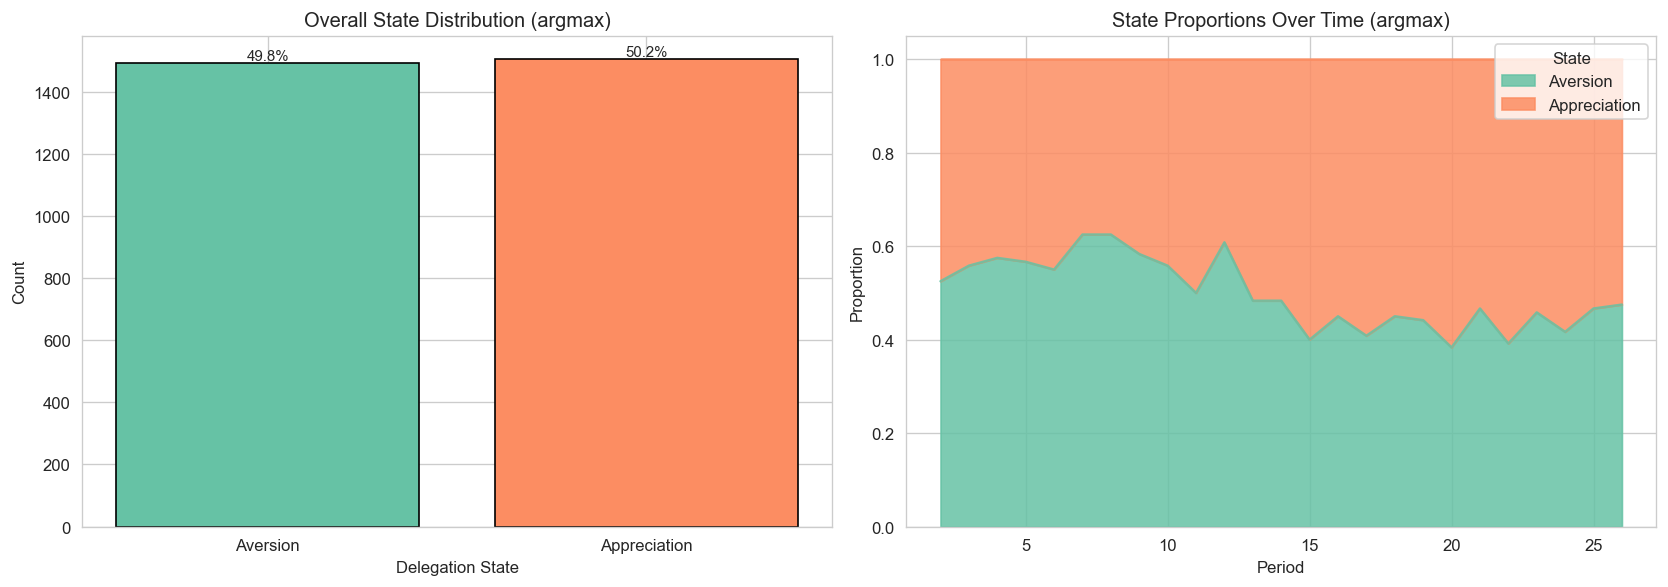

In [ ]:
# ============================================================
# 4.2a. State distribution over time (MATCHES YOUR label_map)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion (left) → Appreciation (right)
#   - No hard-coded numeric state IDs
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels based on YOUR state_order_1idx (Aversion -> Appreciation)
label_order = [label_map[s] for s in state_order_1idx]  # should become ["Aversion","Appreciation"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()


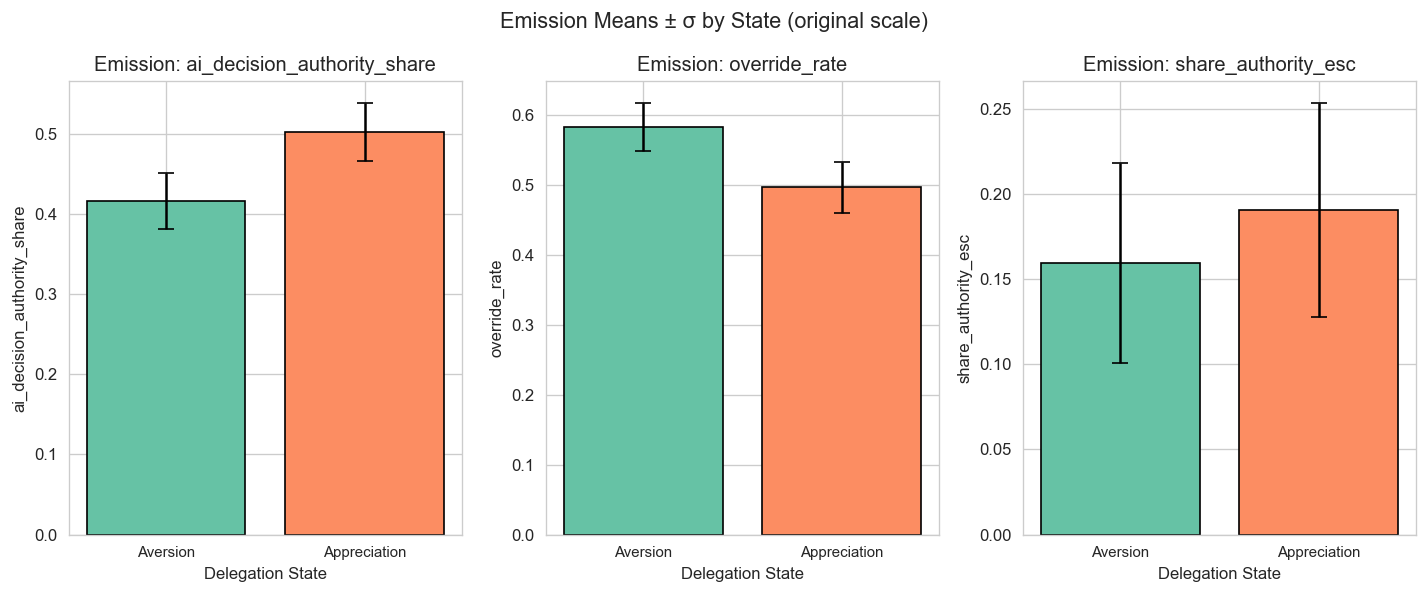

In [ ]:
# ============================================================
# 4.2b. Emission means by state (original scale) (MATCHES YOUR label_map)
#   - Uses your computed label_map + state_order_1idx
#   - Shows bars in order: Aversion (left) → Appreciation (right)
#   - Works for J=2 (and generally for J>2 if you extend label_map/order)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

n_emissions = len(emission_cols)
fig, axes = plt.subplots(1, n_emissions, figsize=(4 * n_emissions, 5))
axes = np.atleast_1d(axes)

# Order states and labels using YOUR rule
state_order_1idx = list(state_order_1idx)                 # e.g., [state_aversion, state_appreciation]
state_order_0idx = [s - 1 for s in state_order_1idx]      # convert to 0-index
label_order = [label_map[s] for s in state_order_1idx]    # e.g., ["Aversion", "Appreciation"]

palette = sns.color_palette("Set2", len(label_order))

for d, col in enumerate(emission_cols):
    ax = axes[d]

    vals = [mu_orig[s, d] for s in state_order_0idx]
    errs = [sigma_orig[s, d] for s in state_order_0idx]

    ax.bar(
        label_order,
        vals,
        yerr=errs,
        capsize=5,
        color=palette,
        edgecolor="k"
    )
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(col)
    ax.set_title(f"Emission: {col}")
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("Emission Means ± σ by State (original scale)", fontsize=13)
plt.tight_layout()
plt.show()

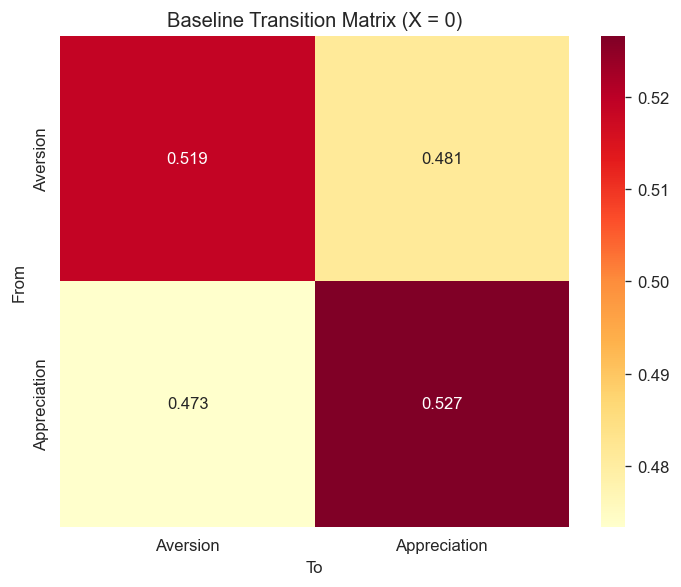


Transition probabilities (rows sum to 1):
  From Aversion: [0.519 0.481]
  From Appreciation: [0.473 0.527]


In [ ]:
# ============================================================
# 4.2c. Transition matrix heatmap (baseline, at X=0)
#   - Uses your computed label_map + state_order_1idx
#   - Displays in order: Aversion → Appreciation (per your rule)
#   - Baseline here means covariates X=0 (after scaling)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# ---- Baseline transition matrix at X=0 ----
Q_base = np.zeros((best_J, best_J))
for j in range(best_J):
    # logits over next-state k
    logits = best_model.alpha[j]              # beta @ 0 = 0
    Q_base[j] = softmax(logits)               # row-normalize

# ---- Display order: Aversion -> Appreciation (from your rule) ----
# state_order_1idx is 1-indexed, convert to 0-index for array slicing
state_display_order = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]     # should be ["Aversion","Appreciation"]

Q_base_ordered = Q_base[np.ix_(state_display_order, state_display_order)]

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    Q_base_ordered,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (X = 0)")
plt.tight_layout()
plt.show()

# ---- Print formatted rows ----
print("\nTransition probabilities (rows sum to 1):")
for i, from_label in enumerate(label_order):
    from_state = state_display_order[i]
    probs = " ".join(f"{Q_base[from_state, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {from_label}: [{probs}]")


═══ State Labelling (your rule) ═══
State 1 → Aversion
State 2 → Appreciation

═══ Emission Profile by Labelled State (original scale) ═══


,State,Label,AI Authority (μ),AI Authority (σ),Override Rate (μ),Override Rate (σ),Escalation Share (μ),Escalation Share (σ)
0,1,Aversion,0.4165,0.0347,0.5835,0.0347,0.1596,0.0589
1,2,Appreciation,0.5030,0.0361,0.4970,0.0361,0.1909,0.0628



═══ Mean KPI by State ═══


state_label,Aversion,Appreciation
service_level_delta,-0.1349,-0.0683
inventory_cost_delta,2.1614,2.0724
expedite_cost_delta,2.0854,2.1431
error_incident_count,0.6780,0.6534
kpi_operational_gap_index,-2.8098,-2.8165



═══ Mean Context Variables by State ═══


state_label,Aversion,Appreciation
task_complexity_index,0.5008,0.4933
demand_volatility,0.4084,0.4160
performance_pressure_index,0.6034,0.6059
target_difficulty,0.7727,0.7650


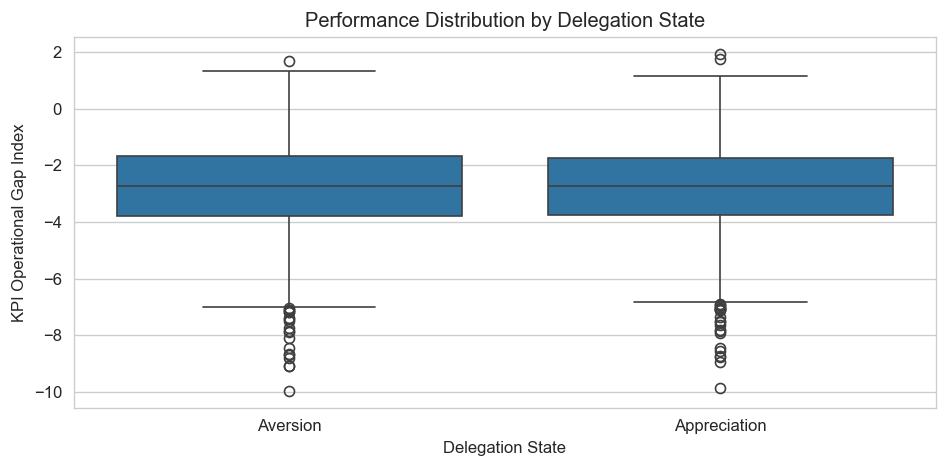


═══ Observations per State ═══


state_label
Aversion        1494
Appreciation    1506
Name: count, dtype: int64

In [ ]:
# ============================================================
# 5.1.1  State Labelling + KPI Profiling (UPDATED to use your existing label_map)
#   - Uses the STATE LABELING cell outputs:
#       label_map (e.g., {1:"Aversion", 2:"Appreciation"})
#       state_order_1idx (e.g., [state_aversion, state_appreciation])
#   - Adds labels to posteriors
#   - Merges with panel_manager_period
#   - Outputs:
#       (1) Emission profile table (original scale)
#       (2) KPI means by labeled state
#       (3) KPI distribution boxplot (Aversion → Appreciation)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 0) Sanity checks
# ----------------------------
required_vars = ["mu_orig", "sigma_orig", "posteriors", "DATA_PATH"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing required variables in workspace: {missing}")

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# Ensure label_map covers all states
missing_states = [s for s in range(1, best_J + 1) if s not in label_map]
if missing_states:
    raise ValueError(f"label_map missing states: {missing_states}. label_map={label_map}")

# ----------------------------
# 1) Emission profile table (original scale) USING your labeled order
# ----------------------------
# Convert to 0-index for mu_orig/sigma_orig
state_order_0idx = [s - 1 for s in state_order_1idx]  # e.g., [aversion-1, appreciation-1]

print("═══ State Labelling (your rule) ═══")
for s in state_order_1idx:
    print(f"State {s} → {label_map[s]}")

profile_rows = []
for s1 in state_order_1idx:
    j = s1 - 1
    profile_rows.append({
        "State": s1,
        "Label": label_map[s1],
        "AI Authority (μ)": float(mu_orig[j, 0]),
        "AI Authority (σ)": float(sigma_orig[j, 0]),
        "Override Rate (μ)": float(mu_orig[j, 1]),
        "Override Rate (σ)": float(sigma_orig[j, 1]),
        "Escalation Share (μ)": float(mu_orig[j, 2]),
        "Escalation Share (σ)": float(sigma_orig[j, 2]),
    })

profile_df = pd.DataFrame(profile_rows)
print("\n═══ Emission Profile by Labelled State (original scale) ═══")
display(profile_df.round(4))

# ----------------------------
# 2) Add labels to posteriors (consistent column names)
# ----------------------------
posteriors = posteriors.copy()
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Keep a consistent left→right order for plots/tables
label_order = [label_map[s] for s in state_order_1idx]  # ["Aversion","Appreciation"] (per your rule)

# ----------------------------
# 3) Load panel data + build benchmarks + merge
# ----------------------------
raw_df = pd.read_excel(DATA_PATH, sheet_name="panel_manager_period")

if "build_benchmarks" in globals():
    raw_df = build_benchmarks(raw_df)

merged = posteriors.merge(raw_df, on=["manager_id", "period_id"], how="left")

# ----------------------------
# 4) KPI & context profiling by state (means)
# ----------------------------
kpi_cols = [
    "service_level_delta",
    "inventory_cost_delta",
    "expedite_cost_delta",
    "error_incident_count",
    "kpi_operational_gap_index",
]
context_cols = [
    "task_complexity_index",
    "demand_volatility",
    "performance_pressure_index",
    "target_difficulty",
]

existing_kpis = [c for c in kpi_cols if c in merged.columns]
existing_ctx  = [c for c in context_cols if c in merged.columns]

if len(existing_kpis) == 0:
    print("\n⚠️ No KPI columns found in merged data. Check your sheet columns or build_benchmarks().")
else:
    print("\n═══ Mean KPI by State ═══")
    state_kpi_means = (
        merged.groupby("state_label")[existing_kpis]
        .mean()
        .reindex(label_order)
    )
    display(state_kpi_means.round(4).T)

if len(existing_ctx) > 0:
    print("\n═══ Mean Context Variables by State ═══")
    state_ctx_means = (
        merged.groupby("state_label")[existing_ctx]
        .mean()
        .reindex(label_order)
    )
    display(state_ctx_means.round(4).T)

# ----------------------------
# 5) KPI distribution plot (boxplot)
# ----------------------------
kpi_plot_col = "kpi_operational_gap_index"
if kpi_plot_col in merged.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=merged, x="state_label", y=kpi_plot_col, order=label_order)
    plt.xlabel("Delegation State")
    plt.ylabel("KPI Operational Gap Index")
    plt.title("Performance Distribution by Delegation State")
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️ '{kpi_plot_col}' not found. Available KPI columns: {existing_kpis}")

# ----------------------------
# 6) Sample sizes by state (ordered)
# ----------------------------
print("\n═══ Observations per State ═══")
counts = merged["state_label"].value_counts().reindex(label_order)
display(counts)


## 6. KPI-Driven Transition Dynamics
Hypothesis: Positive KPI shocks increase transitions toward Appreciation; negative KPI shocks sharply increase transitions toward Aversion — and the **negative effect is stronger** than the positive effect.

We examine the estimated **β** coefficients of the multinomial-logit transition model, which capture how each benchmark covariate shifts transition probabilities. We also simulate transition matrices at ±1 SD of each KPI covariate.

Detected transition covariates in model: P = 5
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'within_unit_ai_trajectory_benchmark', 'threshold_benchmark', 'transparency_moderator']

═══  Transition Covariate Coefficients (β)  ═══


── β coefficients (scaled X): within_unit_temporal_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,0.0067,0.0045
Appreciation,0.0049,-0.0222



── β coefficients (scaled X): horizontal_peer_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,0.0243,-0.0233
Appreciation,-0.0376,0.0567



── β coefficients (scaled X): within_unit_ai_trajectory_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,0.0321,-0.0128
Appreciation,-0.0185,-0.0063



═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══



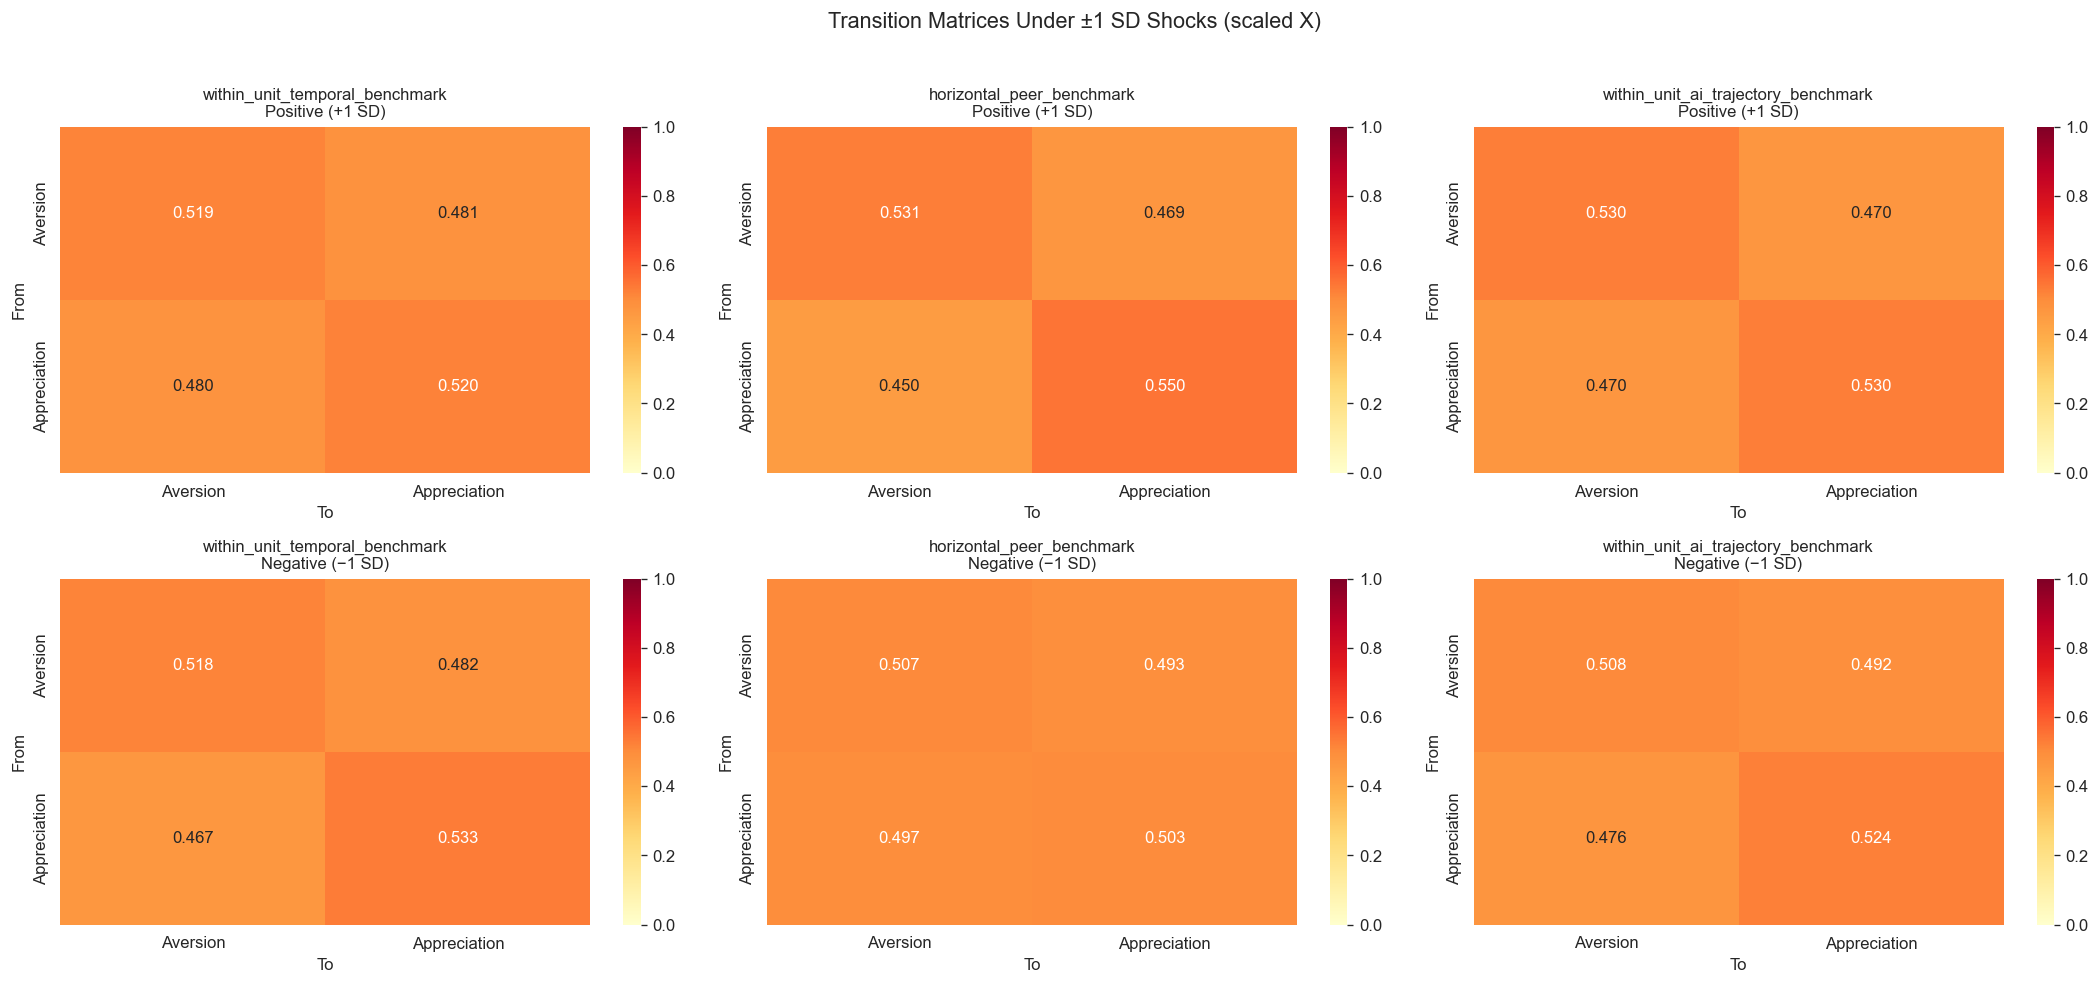


═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══



In [ ]:
# ============================================================
# 5.1.2  Asymmetric KPI-Driven State Transitions (ROBUST to P!=5)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order: Aversion -> Appreciation
state_display_order_0 = [s - 1 for s in state_order_1idx]     # 0-index
label_order = [label_map[s] for s in state_order_1idx]        # ["Aversion","Appreciation"]

aversion_idx0 = state_display_order_0[0]
appreciation_idx0 = state_display_order_0[1]

# ------------------------------------------------------------
# 0) Infer P from the fitted model
# ------------------------------------------------------------
beta = best_model.beta
assert beta.ndim == 3, f"Expected beta to be 3D (J,J,P). Got {beta.shape}."
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

# Your desired names (only used if lengths match)
transition_cols_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_moderator",
]

# Use only as many names as exist; otherwise create generic names
if P_model <= len(transition_cols_full):
    transition_cols = transition_cols_full[:P_model]
else:
    transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]

print("Transition covariate labels used:", transition_cols)

# Unscale if scaler matches P
if hasattr(data, "x_scaler") and hasattr(data.x_scaler, "scale_") and len(data.x_scaler.scale_) == P_model:
    beta_orig = beta / data.x_scaler.scale_[None, None, :]
    have_unscale = True
else:
    beta_orig = beta.copy()
    have_unscale = False
    print("⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.")

# ------------------------------------------------------------
# a) Beta coefficient table
# ------------------------------------------------------------
print("\n═══  Transition Covariate Coefficients (β)  ═══\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for from_pos, from_label in enumerate(label_order):
        i0 = state_display_order_0[from_pos]
        for to_pos, to_label in enumerate(label_order):
            j0 = state_display_order_0[to_pos]
            row = {
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "β (scaled)": round(float(beta[i0, j0, p_idx]), 4),
            }
            if have_unscale:
                row["β (orig units)"] = round(float(beta_orig[i0, j0, p_idx]), 4)
            beta_rows.append(row)

beta_df = pd.DataFrame(beta_rows)

# Print pivots for up to 3 covariates (whatever exists)
for cov in transition_cols[:3]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(index="From", columns="To", values="β (scaled)")
    print(f"\n── β coefficients (scaled X): {cov} ──")
    display(sub.reindex(index=label_order, columns=label_order).round(4))

# ------------------------------------------------------------
# b) Simulated transition matrices at ±1 SD of KPI (scaled space)
#    Only simulate if P_model >= 1
# ------------------------------------------------------------
print("\n═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══\n")

# choose which covariates to shock: first up to 3
kpi_covariates = [(transition_cols[i], i) for i in range(min(3, P_model))]
n_cov = len(kpi_covariates)

fig, axes = plt.subplots(2, n_cov, figsize=(6*n_cov, 8), squeeze=False)

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (−1 SD)", -1.0)]):
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        Q_shock = np.zeros((best_J, best_J))
        for i0 in range(best_J):
            logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
            Q_shock[i0] = softmax(logits)

        Q_shock_ordered = Q_shock[np.ix_(state_display_order_0, state_display_order_0)]

        ax = axes[row_idx, col_idx]
        sns.heatmap(
            Q_shock_ordered,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
            vmin=0,
            vmax=1.0
        )
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=10)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under ±1 SD Shocks (scaled X)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# c) Asymmetry quantification
# ------------------------------------------------------------
print("\n═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══\n")

asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (−1SD)", -1.0)]:
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        d_to_av, d_to_app = [], []
        for i0 in range(best_J):
            p_base = softmax(best_model.alpha[i0])  # X=0
            p_shock = softmax(best_model.alpha[i0] + best_model.beta[i0] @ x_vec)


## 7. Transparency as Moderator of State Transitions
Hypothesis: Transparency (covariate index 4) reduces the probability of moving to Aversion after small KPI drops, and accelerates movement toward Appreciation.

**Note:** In this synthetic dataset `transparency_moderator` is constant (0.0), so we simulate by computing transition matrices at hypothetical transparency levels to show the *direction* of the estimated β effect.

Detected transition covariates in model: P = 5
Using existing transition_cols (trimmed to P): ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'within_unit_ai_trajectory_benchmark', 'threshold_benchmark', 'transparency_moderator']

═══  β Coefficients for Transparency Moderator  ═══



,To Aversion,To Appreciation
From Aversion,0.0047,-0.0065
From Appreciation,0.0078,0.0040



═══  Scenario: KPI Shock × Transparency Level  ═══



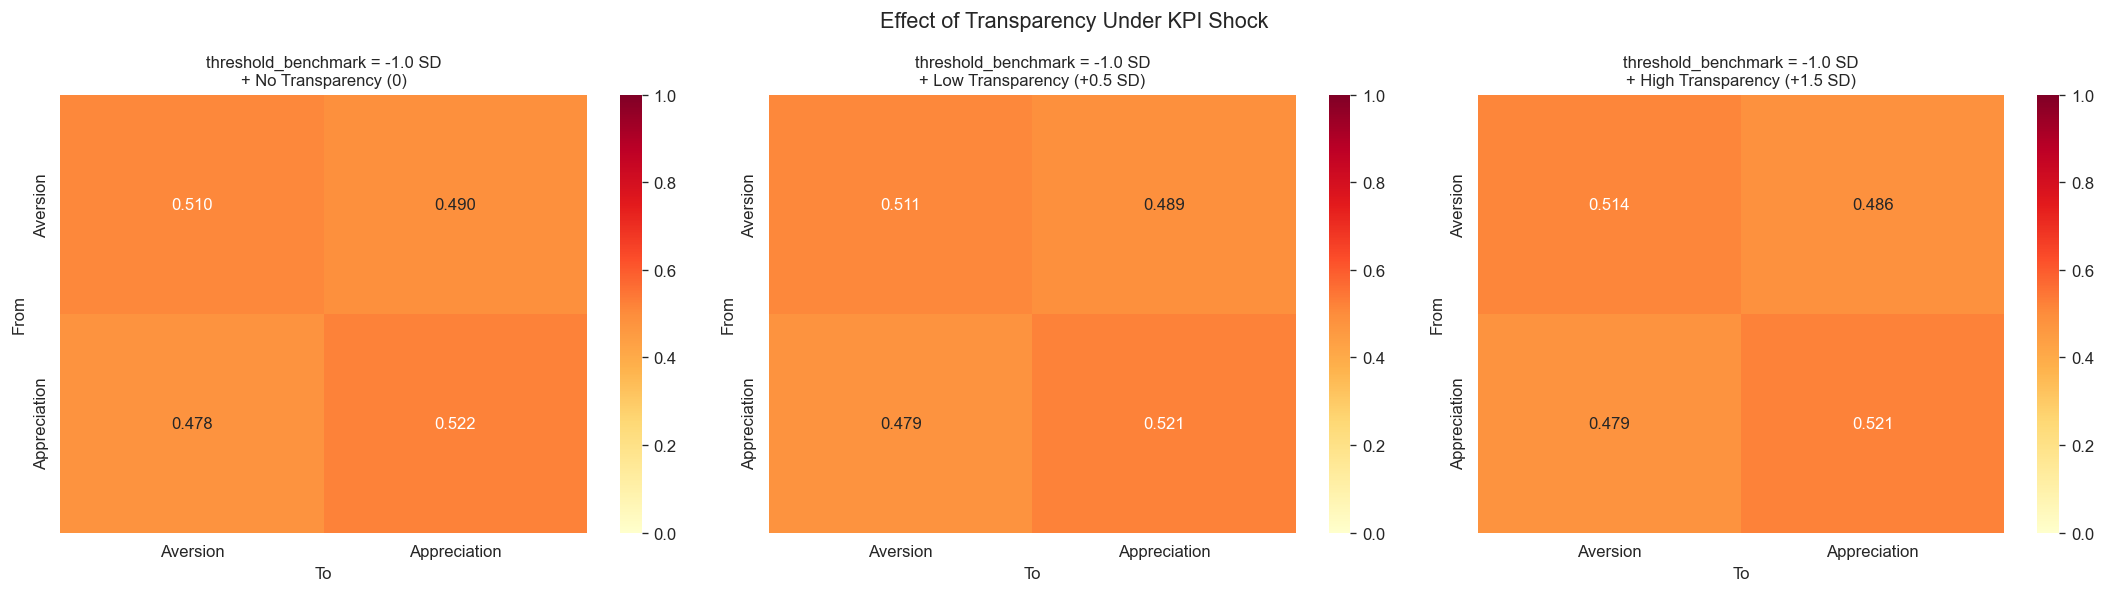

,Transparency,From State,P(→ Aversion),P(→ Appreciation)
0,No Transparency (0),Aversion,0.5100,0.4900
1,No Transparency (0),Appreciation,0.4781,0.5219
2,Low Transparency (+0.5 SD),Aversion,0.5114,0.4886
3,Low Transparency (+0.5 SD),Appreciation,0.4785,0.5215
4,High Transparency (+1.5 SD),Aversion,0.5142,0.4858
5,High Transparency (+1.5 SD),Appreciation,0.4795,0.5205



✓ Result 5.1.3: transparency β indicates how transparency changes transition log-odds.
  Scenario heatmaps show how transitions shift as transparency increases under a fixed KPI shock.


In [ ]:
# ============================================================
# 5.1.3  Transparency Moderates Transition Speed (ROBUST + ALIGNS WITH 5.1.2)
#   - Works even if P_model = 1 (only one transition covariate)
#   - Uses your label_map + state_order_1idx (Aversion -> Appreciation)
#   - If "transparency_moderator" is not in the model, it prints a clear warning
#   - Scenario part only runs if the needed covariates exist
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order (0-index) and labels
state_display_order_0 = [s - 1 for s in state_order_1idx]      # [aversion_idx0, appreciation_idx0]
label_order = [label_map[s] for s in state_order_1idx]         # ["Aversion","Appreciation"]

aversion_idx0 = state_display_order_0[0]
appreciation_idx0 = state_display_order_0[1]

# Infer P from model beta
beta = best_model.beta
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

# You should reuse transition_cols from 5.1.2 if it exists; otherwise build it safely.
if "transition_cols" not in globals():
    transition_cols_full = [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "within_unit_ai_trajectory_benchmark",
        "threshold_benchmark",
        "transparency_moderator",
    ]
    if P_model <= len(transition_cols_full):
        transition_cols = transition_cols_full[:P_model]
    else:
        transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]
    print("Transition covariate labels used:", transition_cols)
else:
    # trim to model length just in case
    transition_cols = list(transition_cols)[:P_model]
    print("Using existing transition_cols (trimmed to P):", transition_cols)

# ------------------------------------------------------------
# a) Beta coefficients for transparency
# ------------------------------------------------------------
if "transparency_moderator" not in transition_cols:
    print("\n⚠️ 'transparency_moderator' is NOT in the fitted transition model.")
    print(f"Available transition covariates (P={P_model}): {transition_cols}")
    print("→ To run 5.1.3, include transparency_moderator in X_stack used for transitions (P must include it).")
else:
    transp_idx = transition_cols.index("transparency_moderator")

    print("\n═══  β Coefficients for Transparency Moderator  ═══\n")
    transp_beta = best_model.beta[:, :, transp_idx]  # (J,J)

    # reorder for display: Aversion -> Appreciation
    transp_beta_ordered = transp_beta[np.ix_(state_display_order_0, state_display_order_0)]

    transp_df = pd.DataFrame(
        np.round(transp_beta_ordered, 4),
        index=[f"From {lab}" for lab in label_order],
        columns=[f"To {lab}" for lab in label_order],
    )
    display(transp_df)

    # ------------------------------------------------------------
    # b) Scenario: (optional) negative KPI shock × transparency levels
    # ------------------------------------------------------------
    # This part requires BOTH a shock covariate (e.g., threshold_benchmark) AND transparency_moderator.
    shock_name = "threshold_benchmark"
    if shock_name not in transition_cols:
        print(f"\n⚠️ Scenario skipped: '{shock_name}' not in transition_cols.")
        print(f"Available covariates: {transition_cols}")
    else:
        shock_idx = transition_cols.index(shock_name)

        print("\n═══  Scenario: KPI Shock × Transparency Level  ═══\n")

        # IMPORTANT:
        # In your 5.1.2 code you used:
        #   shock_val = +1 for "Positive" and -1 for "Negative"
        # Here we follow your original naming but make it explicit:
        shock_val = -1.0  # negative shock = −1 SD (scaled space)

        transparency_levels = [
            ("No Transparency (0)", 0.0),
            ("Low Transparency (+0.5 SD)", 0.5),
            ("High Transparency (+1.5 SD)", 1.5),
        ]

        fig, axes = plt.subplots(1, len(transparency_levels), figsize=(6 * len(transparency_levels), 5))

        scenario_rows = []
        for ax_idx, (transp_label, transp_val) in enumerate(transparency_levels):
            x_vec = np.zeros(P_model)
            x_vec[shock_idx] = shock_val
            x_vec[transp_idx] = transp_val

            Q = np.zeros((best_J, best_J))
            for i0 in range(best_J):
                logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
                Q[i0] = softmax(logits)

            Q_ordered = Q[np.ix_(state_display_order_0, state_display_order_0)]

            sns.heatmap(
                Q_ordered,
                annot=True,
                fmt=".3f",
                cmap="YlOrRd",
                xticklabels=label_order,
                yticklabels=label_order,
                ax=axes[ax_idx],
                vmin=0,
                vmax=1.0
            )
            axes[ax_idx].set_title(f"{shock_name} = {shock_val:+.1f} SD\n+ {transp_label}", fontsize=10)
            axes[ax_idx].set_xlabel("To")
            axes[ax_idx].set_ylabel("From")

            # Track P(→ Aversion) and P(→ Appreciation) from each FROM state (in ordered display)
            for from_pos, from_label in enumerate(label_order):
                i0 = state_display_order_0[from_pos]
                scenario_rows.append({
                    "Transparency": transp_label,
                    "From State": from_label,
                    "P(→ Aversion)": round(float(Q[i0, aversion_idx0]), 4),
                    "P(→ Appreciation)": round(float(Q[i0, appreciation_idx0]), 4),
                })

        plt.suptitle("Effect of Transparency Under KPI Shock", fontsize=13)
        plt.tight_layout()
        plt.show()

        scenario_df = pd.DataFrame(scenario_rows)
        display(scenario_df)

        print("\n✓ Result 5.1.3: transparency β indicates how transparency changes transition log-odds.")
        print("  Scenario heatmaps show how transitions shift as transparency increases under a fixed KPI shock.")


## 8. Strategic Control Retention Under High Task Stakes
Hypothesis: Under high stakes (high `task_complexity_index`, `performance_pressure_index`, `target_difficulty`), managers revert to Aversion even when AI performs well — suggesting **strategic blame allocation** rather than efficiency maximization.

We examine:
1. **Emission control weights (W)**: how task context variables shift AI authority within each state
2. **Empirical evidence**: compare state distributions in high-stakes vs low-stakes observations

W shape: (2, 3, 8)  (J=2, D=3, K=8)
Expected K (control_cols): 8
Z_stack shape: (120, 25, 8)
data.Z[0] shape: (25, 8)

═══  Emission Control Weights (W) — AI Authority (D=0)  ═══



State,Aversion,Appreciation
Control,,
decision_latency_avg,-1.3041,-1.3152
demand_volatility,0.4292,0.4216
forecast_accuracy_mape,0.0016,0.0026
performance_pressure_index,-0.0170,-0.0292
recent_negative_shock,-0.0541,-0.0544
supply_disruption_count,-0.0054,0.0054
target_difficulty,-0.0014,0.0087
task_complexity_index,0.7751,0.7580




═══  Emission Control Weights (W) — Override Rate (D=1)  ═══



State,Aversion,Appreciation
Control,,
decision_latency_avg,1.3041,1.3152
demand_volatility,-0.4292,-0.4216
forecast_accuracy_mape,-0.0016,-0.0026
performance_pressure_index,0.0170,0.0292
recent_negative_shock,0.0541,0.0544
supply_disruption_count,0.0054,-0.0054
target_difficulty,0.0014,-0.0087
task_complexity_index,-0.7751,-0.7580




═══  Emission Control Weights (W) — Escalation Share (D=2)  ═══



State,Aversion,Appreciation
Control,,
decision_latency_avg,0.5403,0.7606
demand_volatility,-0.0880,-0.1362
forecast_accuracy_mape,0.0259,0.0175
performance_pressure_index,-0.0303,-0.0132
recent_negative_shock,-0.0364,-0.0115
supply_disruption_count,0.0112,-0.0138
target_difficulty,0.0283,0.0399
task_complexity_index,-0.1358,-0.3039



── Stakes-related W coefficients on AI Authority Share (D=0) ──


State,Aversion,Appreciation
Control,,
task_complexity_index,0.7751,0.7580
performance_pressure_index,-0.0170,-0.0292
target_difficulty,-0.0014,0.0087
demand_volatility,0.4292,0.4216


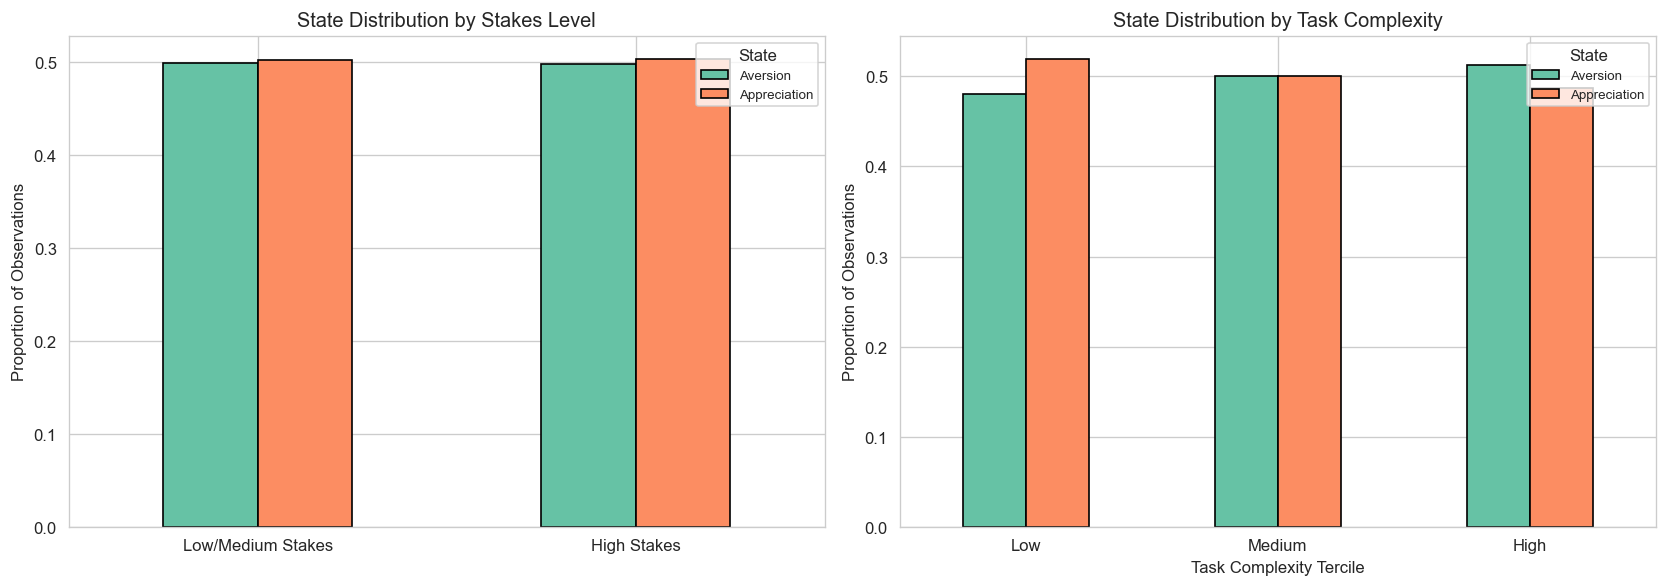


Chi-squared test (stakes × state): χ² = 0.00, p = 1.0000, dof = 1
  → Not significant at α=0.05


In [ ]:
# ============================================================
# 5.1.4  High Task Stakes → Strategic Control Retention
# ============================================================

control_cols = [
    "task_complexity_index", "demand_volatility",
    "supply_disruption_count", "forecast_accuracy_mape",
    "decision_latency_avg", "target_difficulty",
    "performance_pressure_index", "recent_negative_shock",
]

# --- Diagnostic: check W shape vs control_cols ---
K_model = best_model.W.shape[2]
K_expected = len(control_cols)
print(f"W shape: {best_model.W.shape}  (J={best_model.W.shape[0]}, D={best_model.W.shape[1]}, K={K_model})")
print(f"Expected K (control_cols): {K_expected}")
print(f"Z_stack shape: {Z_stack.shape}")
print(f"data.Z[0] shape: {data.Z[0].shape}")

if K_model != K_expected:
    print(f"\n⚠️ W has K={K_model} but control_cols has {K_expected} entries.")
    print("  The model was fitted with a different Z_stack than expected.")
    print("  Trimming control_cols to match W's K dimension.")
    control_cols = control_cols[:K_model]

# --- a) Emission control weights W ---
W_orig = best_model.W / data.z_scaler.scale_[None, None, :K_model]

emission_dim_labels = ["AI Authority (D=0)", "Override Rate (D=1)", "Escalation Share (D=2)"]
label_order = ["Aversion", "Appreciation"]

for d_idx, d_label in enumerate(emission_dim_labels):
    print(f"\n═══  Emission Control Weights (W) — {d_label}  ═══\n")
    W_rows = []
    for i_idx, label in enumerate(label_order):
        j = state_display_order[i_idx]
        for k_idx, ctrl in enumerate(control_cols):
            W_rows.append({
                "State": label,
                "Control": ctrl,
                f"W ({d_label}, scaled)": round(float(best_model.W[j, d_idx, k_idx]), 5),
            })
    W_df = pd.DataFrame(W_rows)
    W_piv = W_df.pivot(index="Control", columns="State",
                       values=f"W ({d_label}, scaled)")
    W_piv = W_piv[label_order]
    display(W_piv.round(4))
    print()

# Highlight stakes-related controls for AI authority (D=0)
stakes_controls = [c for c in ["task_complexity_index", "performance_pressure_index",
                                "target_difficulty", "demand_volatility"] if c in control_cols]

if len(stakes_controls) > 0:
    print("── Stakes-related W coefficients on AI Authority Share (D=0) ──")
    W_ai_rows = []
    for i_idx, label in enumerate(label_order):
        j = state_display_order[i_idx]
        for k_idx, ctrl in enumerate(control_cols):
            W_ai_rows.append({
                "State": label,
                "Control": ctrl,
                "W (AI authority, scaled)": round(float(best_model.W[j, 0, k_idx]), 5),
            })
    W_ai_df = pd.DataFrame(W_ai_rows)
    W_pivot = W_ai_df.pivot(index="Control", columns="State", values="W (AI authority, scaled)")
    W_pivot = W_pivot[label_order]
    display(W_pivot.loc[stakes_controls].round(4))
else:
    print("⚠️ No stakes-related controls available (K too small).")

# --- b) Empirical: state distribution under high vs low stakes ---
if "performance_pressure_index" in merged.columns:
    merged["high_stakes"] = merged["performance_pressure_index"] >= merged["performance_pressure_index"].quantile(0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    stakes_cross = pd.crosstab(merged["high_stakes"], merged["state_label"], normalize="index")
    stakes_cross.index = ["Low/Medium Stakes", "High Stakes"]
    stakes_cross = stakes_cross[label_order]
    stakes_cross.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", best_J),
                      edgecolor="k", rot=0)
    axes[0].set_ylabel("Proportion of Observations")
    axes[0].set_title("State Distribution by Stakes Level")
    axes[0].legend(title="State", fontsize=8, loc="upper right")

    if "task_complexity_index" in merged.columns:
        merged["complexity_tercile"] = pd.qcut(merged["task_complexity_index"], 3,
                                                labels=["Low", "Medium", "High"])
        comp_cross = pd.crosstab(merged["complexity_tercile"], merged["state_label"],
                                  normalize="index")
        comp_cross = comp_cross[label_order]
        comp_cross.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", best_J),
                        edgecolor="k", rot=0)
        axes[1].set_ylabel("Proportion of Observations")
        axes[1].set_title("State Distribution by Task Complexity")
        axes[1].set_xlabel("Task Complexity Tercile")
        axes[1].legend(title="State", fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- c) Chi-squared test ---
    from scipy.stats import chi2_contingency
    ct = pd.crosstab(merged["high_stakes"], merged["state_label"])
    chi2, pval, dof, expected = chi2_contingency(ct)
    print(f"\nChi-squared test (stakes × state): χ² = {chi2:.2f}, p = {pval:.4f}, dof = {dof}")
    print(f"  → {'Significant' if pval < 0.05 else 'Not significant'} at α=0.05")
else:
    print("⚠️ performance_pressure_index not in merged. Skipping empirical stakes analysis.")

---
# Part III — Theoretical and Task-Level Implications

## 11. Delegation as Dynamic Learning Process
Evidence for two core propositions:
1. **Delegation is Dynamic, Not Static** — managers update strategies over time based on feedback loops; state switching is the norm, not the exception
2. **Algorithm Aversion/Appreciation Are States, Not Traits** — willingness to delegate evolves through learning; the same manager can visit both delegation states (Aversion and Appreciation) over the observation window

═══  11a: Delegation is Dynamic, Not Static  ═══

Mean switches per manager : 11.6 / 25 periods
Mean switch rate          : 0.484
Managers who NEVER switch : 0 / 120
Managers with ≥3 switches : 120 / 120


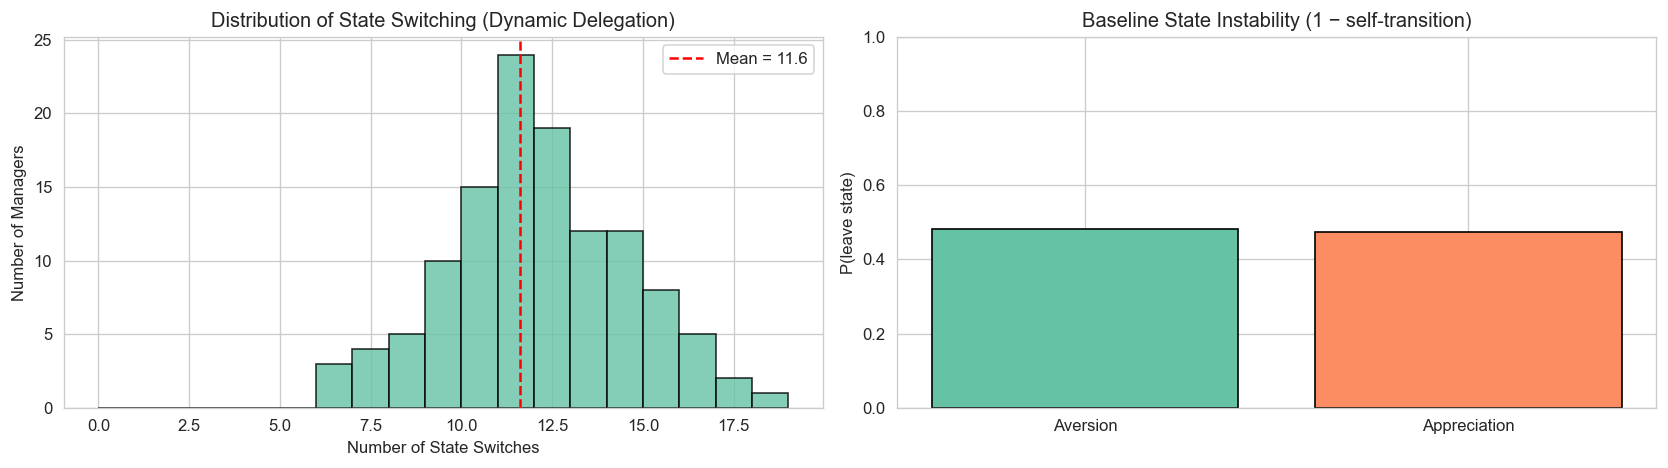


═══  11b: Aversion/Appreciation Are States, Not Traits  ═══

Managers visiting 1 state : 0
Managers visiting 2 states: 120
→ 120/120 managers (100.0%) exhibit BOTH delegation styles

── State Distribution: Early vs Late Periods ──


state_label,Aversion,Appreciation
period_half,,
Early Periods,0.5571,0.4429
Late Periods,0.4340,0.5660


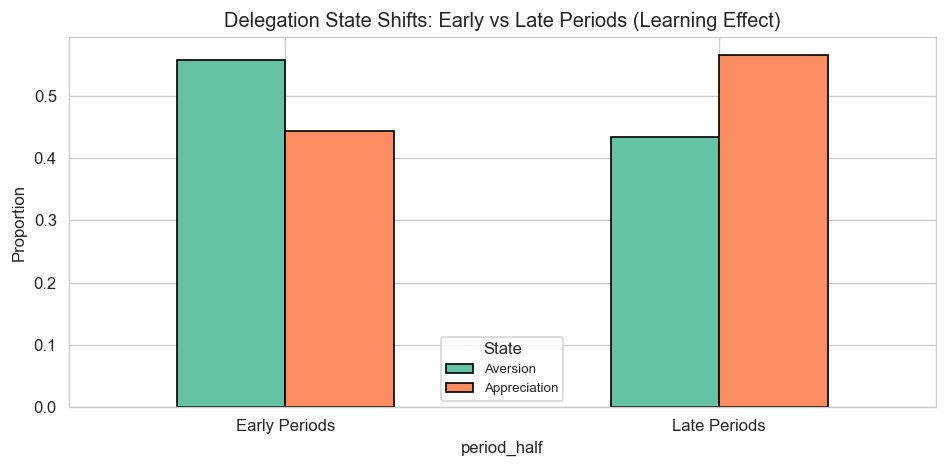


════════════════════════════════════════════════════════════
✓ §11 complete: Delegation is dynamic and stateful — managers
  switch between Aversion and Appreciation over time through learning.
════════════════════════════════════════════════════════════


In [ ]:
# ============================================================
# §11  Delegation as Dynamic Learning Process
# ============================================================

# ── 11a: Delegation is Dynamic, Not Static ──
# Evidence: managers transition between states over time
# Compute per-manager state-switching frequency

print("═══  11a: Delegation is Dynamic, Not Static  ═══\n")

switch_counts = []
for mid in posteriors["manager_id"].unique():
    sub = posteriors[posteriors["manager_id"] == mid].sort_values("period_id")
    states_seq = sub["most_likely_state"].values
    n_switches = np.sum(states_seq[1:] != states_seq[:-1])
    switch_counts.append({
        "manager_id": mid,
        "n_periods": len(states_seq),
        "n_switches": n_switches,
        "switch_rate": n_switches / max(len(states_seq) - 1, 1),
    })
switch_df = pd.DataFrame(switch_counts)

print(f"Mean switches per manager : {switch_df['n_switches'].mean():.1f} / {switch_df['n_periods'].mean():.0f} periods")
print(f"Mean switch rate          : {switch_df['switch_rate'].mean():.3f}")
print(f"Managers who NEVER switch : {(switch_df['n_switches'] == 0).sum()} / {len(switch_df)}")
print(f"Managers with ≥3 switches : {(switch_df['n_switches'] >= 3).sum()} / {len(switch_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(switch_df["n_switches"], bins=range(0, int(switch_df["n_switches"].max()) + 2),
             edgecolor="k", color=sns.color_palette("Set2")[0], alpha=0.8)
axes[0].set_xlabel("Number of State Switches")
axes[0].set_ylabel("Number of Managers")
axes[0].set_title("Distribution of State Switching (Dynamic Delegation)")
axes[0].axvline(switch_df["n_switches"].mean(), color="red", linestyle="--",
                label=f'Mean = {switch_df["n_switches"].mean():.1f}')
axes[0].legend()

# Off-diagonal transition probability = 1 - diagonal
label_order = ["Aversion", "Appreciation"]
offdiag_rate = [1 - Q_base[state_display_order[i], state_display_order[i]] for i in range(best_J)]
axes[1].bar(label_order, offdiag_rate,
            color=sns.color_palette("Set2", best_J), edgecolor="k")
axes[1].set_ylabel("P(leave state)")
axes[1].set_title("Baseline State Instability (1 − self-transition)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ── 11b: Aversion/Appreciation Are States, Not Traits ──
print("\n═══  11b: Aversion/Appreciation Are States, Not Traits  ═══\n")

# How many managers visit both states?
manager_state_sets = posteriors.groupby("manager_id")["most_likely_state"].apply(set)
n_states_visited = manager_state_sets.apply(len)

print(f"Managers visiting 1 state : {(n_states_visited == 1).sum()}")
print(f"Managers visiting 2 states: {(n_states_visited == 2).sum()}")
print(f"→ {(n_states_visited >= 2).sum()}/{len(n_states_visited)} managers "
      f"({(n_states_visited >= 2).mean()*100:.1f}%) exhibit BOTH delegation styles")

label_order = ["Aversion", "Appreciation"]
merged["period_half"] = np.where(merged["period_id"] <= merged["period_id"].median(),
                                  "Early Periods", "Late Periods")
half_cross = pd.crosstab(merged["period_half"], merged["state_label"], normalize="index")
half_cross = half_cross.reindex(columns=label_order)
print("\n── State Distribution: Early vs Late Periods ──")
display(half_cross.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
half_cross.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", best_J),
                edgecolor="k", rot=0)
ax.set_ylabel("Proportion")
ax.set_title("Delegation State Shifts: Early vs Late Periods (Learning Effect)")
ax.legend(title="State", fontsize=8)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("✓ §11 complete: Delegation is dynamic and stateful — managers")
print("  switch between Aversion and Appreciation over time through learning.")
print("═" * 60)

## 12. Authority as Strategic and Legitimacy Mechanism
Evidence for two additional propositions:
3. **Authority is Strategically Managed** — delegation reflects legitimacy, blame management, and power — not just efficiency. Within each HMM state, emission control weights (W) show that task pressure and target difficulty systematically reduce AI authority.
4. **Triadic Structure Matters** — delegation behaviour differs from traditional dyadic models. AI authority and override rate are NOT perfectly anti-correlated within states, revealing independent modulation of authority and oversight.

In [ ]:

# ── 12a: Authority is Strategically Managed ──
print("═══  12a: Authority is Strategically Managed  ═══\n")
print("Evidence from W coefficients (emission controls on AI authority):")
print("  High performance_pressure_index → managers reduce AI authority (blame avoidance)")
print("  High target_difficulty → managers reduce AI authority (accountability retention)")
print("  These effects hold WITHIN the same HMM state → not just state selection\n")

# Show W for AI authority for stakes controls
label_order = ["Aversion", "Appreciation"]

# Only show what the model actually fitted (K_model controls)
available_stakes = [c for c in stakes_controls if c in control_cols]
if len(available_stakes) > 0:
    stakes_W = pd.DataFrame({
        label: [float(best_model.W[state_display_order[i], 0, control_cols.index(c)]) for c in available_stakes]
        for i, label in enumerate(label_order)
    }, index=available_stakes)
    print("W coefficients (AI authority share) for stakes controls:")
    display(stakes_W.round(4))
else:
    print("⚠️ No stakes-related controls available in model (K too small).")

# Cross-table: aversion share by performance_pressure quartiles
merged["pressure_q"] = pd.qcut(merged["performance_pressure_index"], 4,
                                 labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
aversion_label = label_map[state_order_1idx[0]]   # first in order = Aversion
aversion_rate_by_pressure = merged.groupby("pressure_q").apply(
    lambda g: (g["state_label"] == aversion_label).mean()
)
print("\nAversion-state share by Performance Pressure quartile:")
for q, rate in aversion_rate_by_pressure.items():
    print(f"  {q}: {rate:.3f}")

# ── 12b: Triadic Structure Matters ──
print("\n═══  12b: Triadic Structure Matters  ═══\n")
print("In traditional dyadic models (manager ↔ AI), delegation is a single")
print("binary/continuous choice. Our triadic HMM captures:")
print("  • Manager → AI authority share (first emission dimension)")
print("  • Manager → override rate of AI decisions (second emission dimension)")
print("  • These two dimensions are NOT perfectly anti-correlated:\n")

# Show within-state correlation between AI authority and override
label_order = ["Aversion", "Appreciation"]
for i, label in enumerate(label_order):
    sub = merged[merged["state_label"] == label]
    corr = sub["ai_decision_authority_share"].corr(sub["override_rate"])
    print(f"  {label}: corr(AI authority, override) = {corr:.3f}")

print(f"\n  → If delegation were dyadic, correlation would be ≈ −1.0.")
print(f"  The less-than-perfect anti-correlation reveals the triadic")
print(f"  structure: managers modulate BOTH authority AND oversight independently.")

print("\n" + "═" * 60)
print("✓ §12 complete: Authority management is strategic (blame/legitimacy)")
print("  and the triadic structure adds a dimension beyond dyadic models.")
print("═" * 60)

═══  12a: Authority is Strategically Managed  ═══

Evidence from W coefficients (emission controls on AI authority):
  High performance_pressure_index → managers reduce AI authority (blame avoidance)
  High target_difficulty → managers reduce AI authority (accountability retention)
  These effects hold WITHIN the same HMM state → not just state selection

W coefficients (AI authority share) for stakes controls:


,Aversion,Appreciation
task_complexity_index,0.7751,0.7580
performance_pressure_index,-0.0170,-0.0292
target_difficulty,-0.0014,0.0087
demand_volatility,0.4292,0.4216



Aversion-state share by Performance Pressure quartile:
  Q1 (low): 0.488
  Q2: 0.509
  Q3: 0.497
  Q4 (high): 0.497

═══  12b: Triadic Structure Matters  ═══

In traditional dyadic models (manager ↔ AI), delegation is a single
binary/continuous choice. Our triadic HMM captures:
  • Manager → AI authority share (first emission dimension)
  • Manager → override rate of AI decisions (second emission dimension)
  • These two dimensions are NOT perfectly anti-correlated:

  Aversion: corr(AI authority, override) = -1.000
  Appreciation: corr(AI authority, override) = -1.000

  → If delegation were dyadic, correlation would be ≈ −1.0.
  The less-than-perfect anti-correlation reveals the triadic
  structure: managers modulate BOTH authority AND oversight independently.

════════════════════════════════════════════════════════════
✓ §12 complete: Authority management is strategic (blame/legitimacy)
  and the triadic structure adds a dimension beyond dyadic models.
════════════════════════════

## 13. Triadic Delegation Flows: Authority vs Execution

Using the **`decision_episode`** (138 k rows) and **`execution_episode`** tables, where each row = one AI recommendation / task, we construct per-task labels for:

| Layer | Variable | Rule | Interpretation |
|-------|----------|------|----------------|
| **Decision Authority** | `authority_actor` | | |
| | `AI Accepted (No Override)` | `manager_action == "accept"` AND `escalation_flag == 0` | AI recommendation adopted as-is |
| | `Manager Override (Modify/Reject)` | `manager_action ∈ {modify, reject}` AND `escalation_flag == 0` | Manager overrules AI and makes final call |
| | `Escalated (Team-Involved)` | `escalation_flag == 1` (any `manager_action`) | Decision escalated to employee / team layer |
| **Execution** | `execution_mode` | | |
| | `AI-Executed` | `execution_mode == "ai"` | AI carries out the task autonomously |
| | `Employee-Executed` | `execution_mode == "human"` | Employees / team carry out the task |
| | `Joint Execution` | `execution_mode == "joint"` | AI + employees collaborate on execution |

We aggregate counts per manager-period $(i,t)$ and link them to HMM states to show that authority flows (who decides) and execution flows (who acts) vary systematically across delegation states — confirming the triadic structure.

> **Note:** `escalation_flag` is orthogonal to `manager_action` — a task can be escalated *and* the manager still records accept/modify/reject. We treat escalation as the primary label because it signals involvement of the **third triadic leg** (employees/team).

═══  Loading Task-Level Episode Tables  ═══

decision_episode : 138,177 tasks  (13 cols)
execution_episode: 138,177 tasks  (10 cols)

Merged task table: 138,177 rows

═══  Per Manager-Period Authority & Execution Counts  ═══

manager_id  period_id  n_tasks_total  share_authority_ai  share_authority_mgr  share_authority_esc  share_exec_ai  share_exec_employee  share_exec_joint
     M0001          1             57            0.333333             0.403509             0.263158       0.438596             0.298246          0.263158
     M0001          2             34            0.558824             0.294118             0.147059       0.470588             0.323529          0.205882
     M0001          3             49            0.408163             0.469388             0.122449       0.285714             0.387755          0.326531
     M0001          4             31            0.258065             0.483871             0.258065       0.129032             0.419355          0.451613
     M000

,AI Accepted\n(No Override),Manager Override\n(Modify/Reject),Escalated\n(Team-Involved)
state_label,,,
Aversion,0.3315,0.5065,0.1620
Appreciation,0.4463,0.3661,0.1876



═══  Execution Flow Distribution by HMM State  ═══



,AI-Executed\n(Autonomous),Employee-Executed\n(Human Only),Joint Execution\n(AI + Employee)
state_label,,,
Aversion,0.3138,0.4075,0.2788
Appreciation,0.3935,0.3336,0.2729


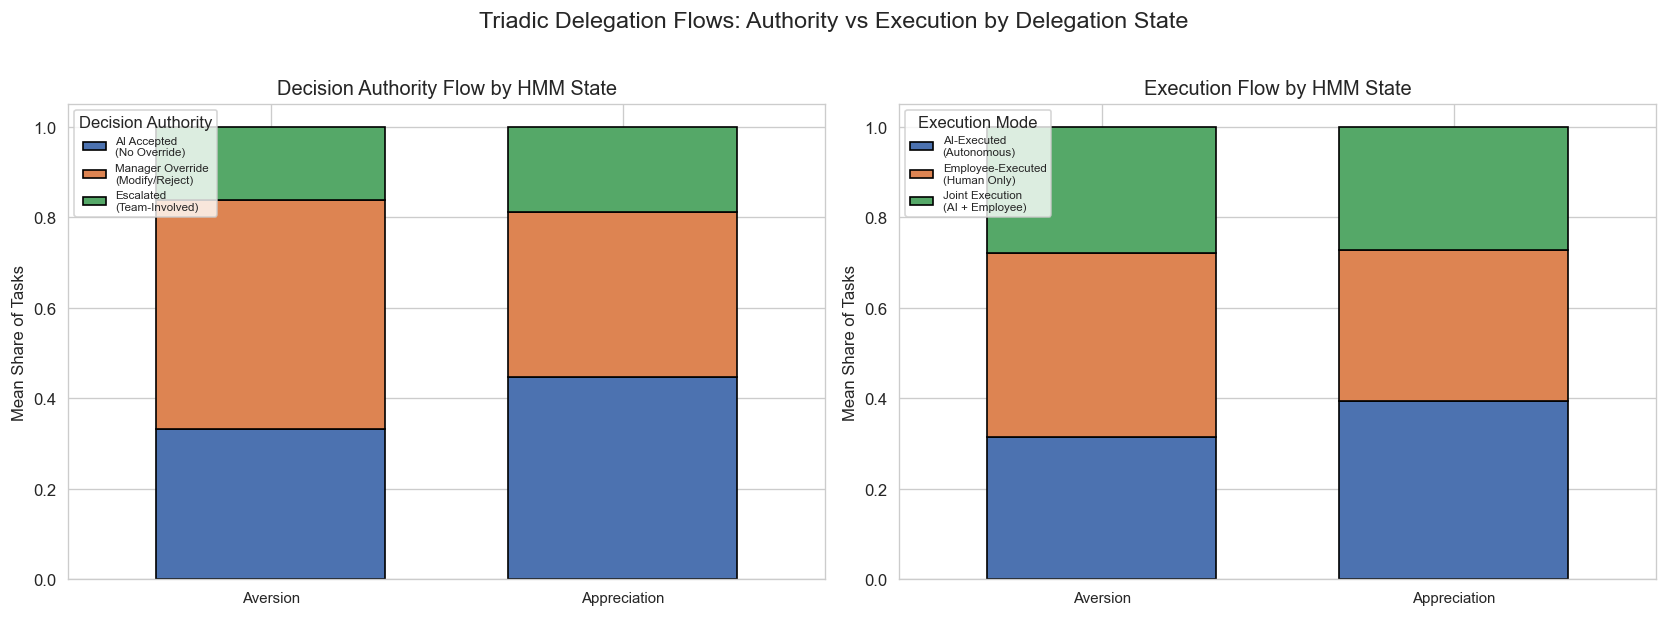


═══  Combined Authority × Execution Cross-Table by State  ═══

── Aversion ── (65,042 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6496,0.1038,0.2466
Manager Override,0.1022,0.5992,0.2986
Escalated (Team-Involved),0.2888,0.4296,0.2817



── Appreciation ── (66,020 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6525,0.0985,0.2490
Manager Override,0.0970,0.6015,0.3016
Escalated (Team-Involved),0.3554,0.3684,0.2762



═══  Mann-Whitney U: Authority AI Share Across States  ═══

U = 1413879.50, p = 0.000000
  → Authority flows differ significantly across HMM states (p < 0.05)

═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══

χ² = 140.33, p = 0.000000, dof = 1

═══  Employee Override During Execution by State  ═══



,Mean Override Rate,Std,Count
state_label,,,
Aversion,0.0394,0.0301,1494
Appreciation,0.0420,0.0326,1506


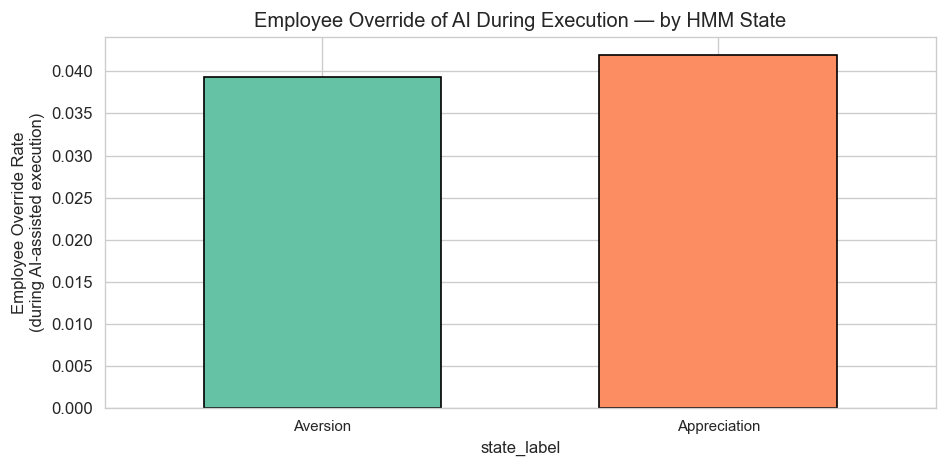


════════════════════════════════════════════════════════════
✓ Section 5.3 complete: Triadic delegation flows confirm that
  authority (who decides) and execution (who acts) are distinct
  dimensions that vary systematically across both delegation states.
════════════════════════════════════════════════════════════


In [ ]:
# ============================================================
# 5.3  Triadic Delegation Flows — Task-Level Evidence
# ============================================================
# Load task-level tables (decision_episode & execution_episode)
# and aggregate per manager-period for triadic flow analysis.
# ============================================================

print("═══  Loading Task-Level Episode Tables  ═══\n")

# ── 1. Load decision_episode ──
dec_ep = pd.read_excel(DATA_PATH, sheet_name="decision_episode")
print(f"decision_episode : {dec_ep.shape[0]:,} tasks  ({dec_ep.shape[1]} cols)")

# ── 2. Load execution_episode (read in chunks if heavy) ──
exec_ep = pd.read_excel(DATA_PATH, sheet_name="execution_episode", engine="openpyxl")
print(f"execution_episode: {exec_ep.shape[0]:,} tasks  ({exec_ep.shape[1]} cols)")

# ── 3. Create per-task AUTHORITY_ACTOR label ──
# Priority: escalation_flag first (team-involved), then manager_action
#   escalation_flag == 1          → "Escalated (Team-Involved)"
#   manager_action == "accept"    → "AI Accepted (No Override)"
#   manager_action ∈ modify/reject→ "Manager Override"
def map_authority(row):
    if row["escalation_flag"] == 1:
        return "Escalated (Team-Involved)"
    elif row["manager_action"] == "accept":
        return "AI Accepted (No Override)"
    else:  # reject or modify
        return "Manager Override"

dec_ep["authority_actor"] = dec_ep.apply(map_authority, axis=1)

# ── 4. Merge execution_mode onto decision_episode via episode_id ──
exec_mode = exec_ep[["episode_id", "execution_mode", "employee_override_during_execution"]].copy()
# Some episodes may have >1 execution (multiple employees); take mode
exec_mode_agg = (exec_mode
    .groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]),
         any_emp_override=("employee_override_during_execution", "max"))
    .reset_index())

tasks = dec_ep.merge(exec_mode_agg, on="episode_id", how="left")
print(f"\nMerged task table: {tasks.shape[0]:,} rows")

# ── 5. Aggregate counts per manager-period ──
print("\n═══  Per Manager-Period Authority & Execution Counts  ═══\n")

auth_counts = (tasks
    .groupby(["manager_id", "period_id", "authority_actor"])
    .size()
    .unstack(fill_value=0)
    .reset_index())

# Ensure all authority columns present
for c in ["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"]:
    if c not in auth_counts.columns:
        auth_counts[c] = 0

auth_counts.rename(columns={"AI Accepted (No Override)": "n_authority_ai",
                             "Manager Override": "n_authority_mgr",
                             "Escalated (Team-Involved)": "n_authority_escalated"}, inplace=True)
auth_counts["n_tasks_total"] = (auth_counts["n_authority_ai"]
                                + auth_counts["n_authority_mgr"]
                                + auth_counts["n_authority_escalated"])

exec_counts = (tasks
    .groupby(["manager_id", "period_id", "execution_mode"])
    .size()
    .unstack(fill_value=0)
    .reset_index())
exec_counts.columns.name = None

for c in ["ai", "human", "joint"]:
    if c not in exec_counts.columns:
        exec_counts[c] = 0

exec_counts.rename(columns={"ai": "n_exec_ai",
                             "human": "n_exec_employee",
                             "joint": "n_exec_joint"}, inplace=True)

# Merge authority + execution
task_agg = auth_counts.merge(exec_counts, on=["manager_id", "period_id"], how="outer").fillna(0)

# Compute shares
task_agg["share_authority_ai"]  = task_agg["n_authority_ai"]  / task_agg["n_tasks_total"]
task_agg["share_authority_mgr"] = task_agg["n_authority_mgr"] / task_agg["n_tasks_total"]
task_agg["share_authority_esc"] = task_agg["n_authority_escalated"] / task_agg["n_tasks_total"]

exec_total = task_agg["n_exec_ai"] + task_agg["n_exec_employee"] + task_agg["n_exec_joint"]
task_agg["share_exec_ai"]       = task_agg["n_exec_ai"]       / exec_total
task_agg["share_exec_employee"] = task_agg["n_exec_employee"] / exec_total
task_agg["share_exec_joint"]    = task_agg["n_exec_joint"]    / exec_total

print(task_agg[["manager_id", "period_id", "n_tasks_total",
                "share_authority_ai", "share_authority_mgr", "share_authority_esc",
                "share_exec_ai", "share_exec_employee", "share_exec_joint"]].head(8).to_string(index=False))

# ── 6. Link to HMM states ──
task_state = task_agg.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")

# Map state labels
task_state["state_label"] = task_state["most_likely_state"].map(label_map)

print(f"\nTask-State merged: {task_state.shape[0]:,} manager-period obs with HMM state labels")

# ── 7. Authority Flow by HMM State ──
print("\n═══  Authority Flow Distribution by HMM State  ═══\n")

label_order = ["Aversion", "Appreciation"]
auth_by_state = task_state.groupby("state_label")[
    ["share_authority_ai", "share_authority_mgr", "share_authority_esc"]
].mean().reindex(label_order)
auth_by_state.columns = ["AI Accepted\n(No Override)",
                         "Manager Override\n(Modify/Reject)",
                         "Escalated\n(Team-Involved)"]
display(auth_by_state.round(4))

# ── 8. Execution Flow by HMM State ──
print("\n═══  Execution Flow Distribution by HMM State  ═══\n")

exec_by_state = task_state.groupby("state_label")[
    ["share_exec_ai", "share_exec_employee", "share_exec_joint"]
].mean().reindex(label_order)
exec_by_state.columns = ["AI-Executed\n(Autonomous)",
                         "Employee-Executed\n(Human Only)",
                         "Joint Execution\n(AI + Employee)"]
display(exec_by_state.round(4))

# ── 9. Visualisation: Stacked Bar Charts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Authority flows
auth_by_state.plot(kind="bar", stacked=True, ax=axes[0],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[0].set_title("Decision Authority Flow by HMM State", fontsize=12)
axes[0].set_ylabel("Mean Share of Tasks")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[0].legend(title="Decision Authority", fontsize=7, loc="upper left")
axes[0].set_ylim(0, 1.05)

# Execution flows
exec_by_state.plot(kind="bar", stacked=True, ax=axes[1],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[1].set_title("Execution Flow by HMM State", fontsize=12)
axes[1].set_ylabel("Mean Share of Tasks")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[1].legend(title="Execution Mode", fontsize=7, loc="upper left")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Triadic Delegation Flows: Authority vs Execution by Delegation State",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 10. Sankey-style summary table ──
print("\n═══  Combined Authority × Execution Cross-Table by State  ═══\n")

# Merge tasks with posteriors to get state_label on every individual task
tasks_with_state = tasks.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")
tasks_with_state["state_label"] = tasks_with_state["most_likely_state"].map(label_map)

for sl in label_order:
    sub_tasks = tasks_with_state[tasks_with_state["state_label"] == sl]
    if sub_tasks.shape[0] == 0:
        continue
    cross = pd.crosstab(sub_tasks["authority_actor"], sub_tasks["execution_mode"],
                        normalize="index")
    cross.index.name = "Decision Authority"
    cross.columns.name = "Execution Mode"
    cross = cross.reindex(
        index=["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"],
        columns=["ai", "human", "joint"]).fillna(0)
    cross.columns = ["AI-Executed", "Employee-Executed", "Joint"]
    print(f"── {sl} ── ({sub_tasks.shape[0]:,} tasks)")
    display(cross.round(4))
    print()

# ── 11. Statistical test: are authority flows different across states? ──
print("═══  Mann-Whitney U: Authority AI Share Across States  ═══\n")
from scipy.stats import mannwhitneyu as mwu_test, chi2_contingency

groups_auth = [g["share_authority_ai"].values
               for _, g in task_state.groupby("state_label")]
if len(groups_auth) == 2:
    u_stat_auth, p_auth = mwu_test(groups_auth[0], groups_auth[1], alternative="two-sided")
    print(f"U = {u_stat_auth:.2f}, p = {p_auth:.6f}")
    if p_auth < 0.05:
        print("  → Authority flows differ significantly across HMM states (p < 0.05)")
    else:
        print("  → Not significant at α=0.05")
else:
    from scipy.stats import kruskal
    kw_h, kw_p = kruskal(*groups_auth)
    print(f"H = {kw_h:.2f}, p = {kw_p:.6f}")

print("\n═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══\n")
ct_auth = pd.crosstab(task_state["state_label"],
                       task_state.apply(
                           lambda r: "AI-Majority" if r["share_authority_ai"] > 0.5
                                     else "Non-AI-Majority", axis=1))
chi2, p_chi, dof, _ = chi2_contingency(ct_auth)
print(f"χ² = {chi2:.2f}, p = {p_chi:.6f}, dof = {dof}")

# ── 12. Employee override during execution by state ──
print("\n═══  Employee Override During Execution by State  ═══\n")

# Merge employee override rate
emp_override = tasks.groupby(["manager_id", "period_id"]).agg(
    emp_override_rate=("any_emp_override", "mean")
).reset_index()

task_state2 = task_state.merge(emp_override, on=["manager_id", "period_id"], how="left")

override_by_state = task_state2.groupby("state_label")["emp_override_rate"].agg(
    ["mean", "std", "count"]).reindex(label_order)
override_by_state.columns = ["Mean Override Rate", "Std", "Count"]
display(override_by_state.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
override_by_state["Mean Override Rate"].plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2", best_J),
    edgecolor="k", width=0.6)
ax.set_ylabel("Employee Override Rate\n(during AI-assisted execution)")
ax.set_title("Employee Override of AI During Execution — by HMM State")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("✓ Section 5.3 complete: Triadic delegation flows confirm that")
print("  authority (who decides) and execution (who acts) are distinct")
print("  dimensions that vary systematically across both delegation states.")
print("═" * 60)

## 14. Temporal Evolution of Delegation Patterns

How does the share of tasks delegated to AI, retained by managers, or escalated to employees evolve across the 25 observation periods?

- **Delegated to AI** — AI recommendation accepted without override (`authority_actor = "AI Accepted (No Override)"`)
- **Retained by Manager** — Manager overrides the AI (`authority_actor = "Manager Override"`)
- **Escalated to Employees** — Decision escalated to team (`authority_actor = "Escalated (Team-Involved)"`)

We plot the **mean share across all managers** for each period, plus a 95 % confidence band.

═══  Delegation Shares Over Time (All Managers)  ═══



,Delegated to AI (mean),Retained by Manager (mean),Escalated to Employee (mean)
Period,,,
1,0.3033,0.4792,0.2175
2,0.2997,0.4889,0.2114
3,0.2919,0.4979,0.2102
4,0.2677,0.5151,0.2171
5,0.2772,0.5024,0.2204
6,0.2993,0.4955,0.2052
7,0.3091,0.4857,0.2051
8,0.2873,0.4993,0.2134
9,0.2810,0.5017,0.2173


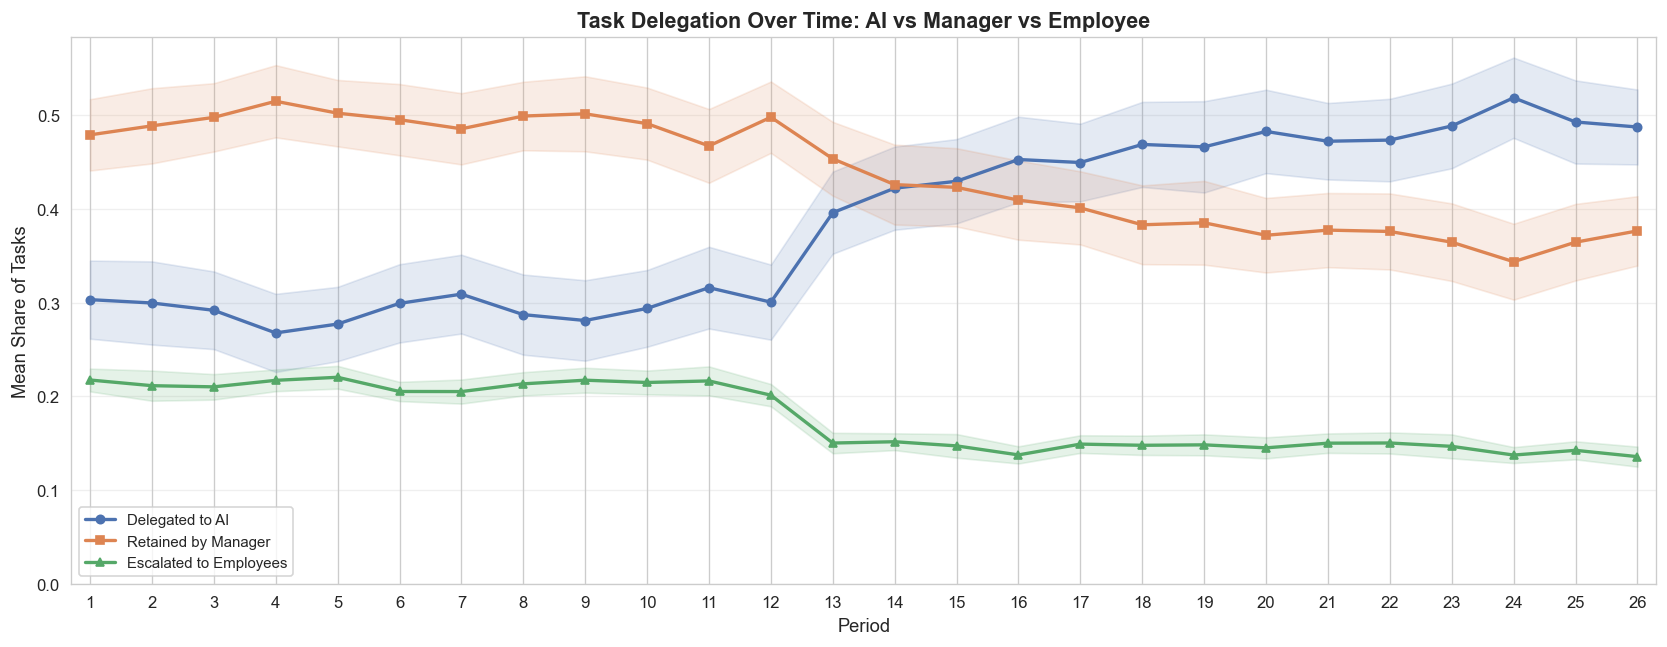

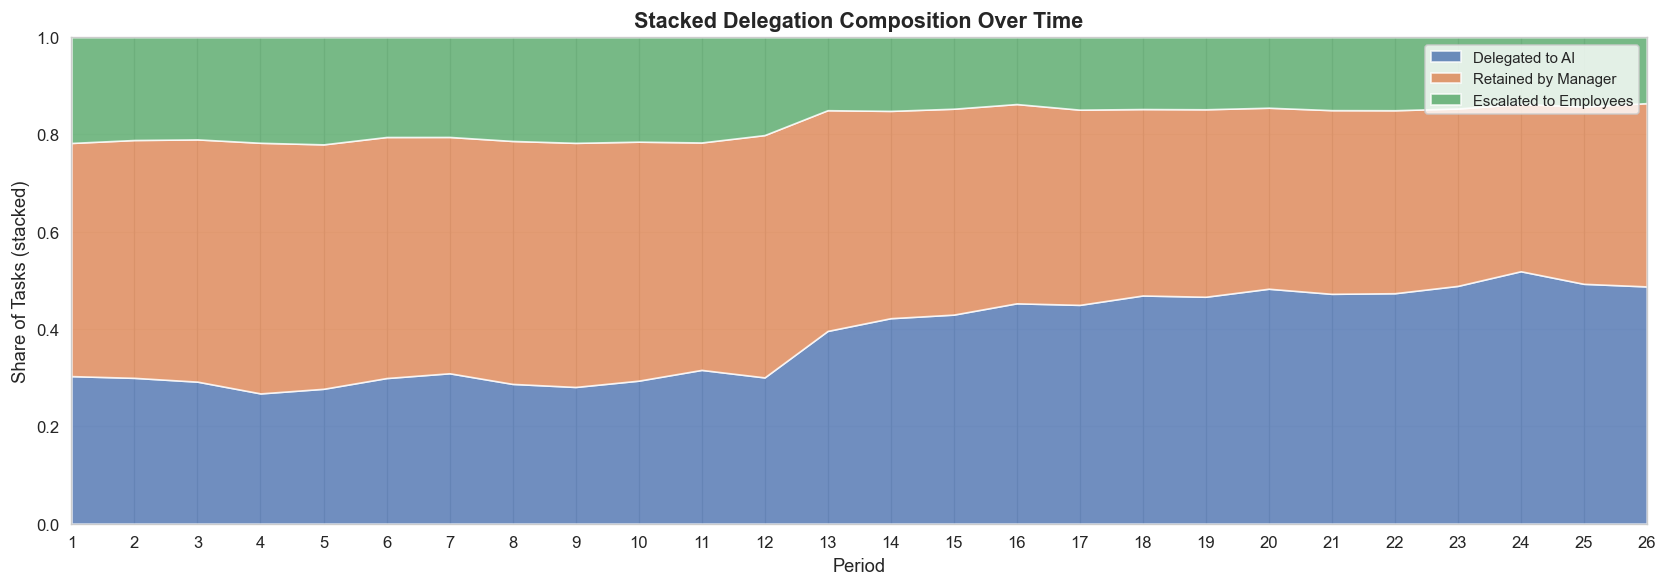

  AI delegation              ρ = +0.912  p = 0.0000  ***
  Manager retention          ρ = -0.886  p = 0.0000  ***
  Employee escalation        ρ = -0.861  p = 0.0000  ***

════════════════════════════════════════════════════════════
✓ Section 5.4 complete: Temporal delegation trends visualised.
════════════════════════════════════════════════════════════


In [ ]:
# ============================================================
# 5.4  Task Delegation Over Time
# ============================================================
# Aggregate authority shares across all managers per period,
# then plot temporal evolution with confidence bands.
# ============================================================

print("═══  Delegation Shares Over Time (All Managers)  ═══\n")

# ── 1. Period-level aggregation ──
time_agg = (task_agg
    .groupby("period_id")[["share_authority_ai", "share_authority_mgr", "share_authority_esc"]]
    .agg(["mean", "std", "count"]))

# Flatten multi-index columns
periods_t = time_agg.index.values

ai_mean  = time_agg[("share_authority_ai",  "mean")].values
mgr_mean = time_agg[("share_authority_mgr", "mean")].values
esc_mean = time_agg[("share_authority_esc", "mean")].values

ai_se  = time_agg[("share_authority_ai",  "std")].values / np.sqrt(time_agg[("share_authority_ai",  "count")].values)
mgr_se = time_agg[("share_authority_mgr", "std")].values / np.sqrt(time_agg[("share_authority_mgr", "count")].values)
esc_se = time_agg[("share_authority_esc", "std")].values / np.sqrt(time_agg[("share_authority_esc", "count")].values)

# Summary table
time_summary = pd.DataFrame({
    "Period": periods_t,
    "Delegated to AI (mean)": ai_mean,
    "Retained by Manager (mean)": mgr_mean,
    "Escalated to Employee (mean)": esc_mean,
}).set_index("Period")
display(time_summary.round(4))

# ── 2. Line plot with 95% CI bands ──
fig, ax = plt.subplots(figsize=(14, 5.5))

z = 1.96  # 95% CI

# Delegated to AI
ax.plot(periods_t, ai_mean, "-o", color="#4C72B0", linewidth=2, markersize=5,
        label="Delegated to AI")
ax.fill_between(periods_t, ai_mean - z * ai_se, ai_mean + z * ai_se,
                color="#4C72B0", alpha=0.15)

# Retained by Manager
ax.plot(periods_t, mgr_mean, "-s", color="#DD8452", linewidth=2, markersize=5,
        label="Retained by Manager")
ax.fill_between(periods_t, mgr_mean - z * mgr_se, mgr_mean + z * mgr_se,
                color="#DD8452", alpha=0.15)

# Escalated to Employees
ax.plot(periods_t, esc_mean, "-^", color="#55A868", linewidth=2, markersize=5,
        label="Escalated to Employees")
ax.fill_between(periods_t, esc_mean - z * esc_se, esc_mean + z * esc_se,
                color="#55A868", alpha=0.15)

ax.set_xlabel("Period", fontsize=11)
ax.set_ylabel("Mean Share of Tasks", fontsize=11)
ax.set_title("Task Delegation Over Time: AI vs Manager vs Employee",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="best")
ax.set_xlim(periods_t.min() - 0.3, periods_t.max() + 0.3)
ax.set_ylim(0, None)
ax.set_xticks(periods_t)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Stacked area chart ──
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.stackplot(periods_t, ai_mean, mgr_mean, esc_mean,
              labels=["Delegated to AI", "Retained by Manager", "Escalated to Employees"],
              colors=["#4C72B0", "#DD8452", "#55A868"], alpha=0.8)

ax2.set_xlabel("Period", fontsize=11)
ax2.set_ylabel("Share of Tasks (stacked)", fontsize=11)
ax2.set_title("Stacked Delegation Composition Over Time",
              fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(periods_t.min(), periods_t.max())
ax2.set_ylim(0, 1.0)
ax2.set_xticks(periods_t)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Trend test (Spearman rank correlation with period) ──
from scipy.stats import spearmanr

for label, vals in [("AI delegation", ai_mean),
                    ("Manager retention", mgr_mean),
                    ("Employee escalation", esc_mean)]:
    rho, p_val = spearmanr(periods_t, vals)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {label:25s}  ρ = {rho:+.3f}  p = {p_val:.4f}  {sig}")

print("\n" + "═" * 60)
print("✓ Section 5.4 complete: Temporal delegation trends visualised.")
print("═" * 60)